<a href="https://colab.research.google.com/github/pandeychetanya/HalloweenFlutter/blob/main/Forecasting_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

sns.set(style='whitegrid')

## Load and clean data




In [ ]:
data = pd.read_csv('/content/OpenWeatherMap_Data.csv')

FileNotFoundError: [Errno 2] No such file or directory: '/content/OpenWeatherMap_Data.csv'

In [ ]:
f = data.copy()

# Convert Unix timestamp to UTC datetime
df['dt'] = pd.to_datetime(df['dt'].astype(int), unit='s', utc=True)

# Use the timezone offset column (in seconds) to compute local time
df['timezone_offset'] = pd.to_timedelta(df['timezone'], unit='s')
d
# Apply the offset to get local time
df['dt_local'] = df['dt'] + df['timezone_offset']

# Set local time as index
df = df.set_index('dt_local').sort_index()

df.head(20)

NameError: name 'data' is not defined

In [ ]:
# Extract the local month for grouping
df = df.reset_index()
df['month'] = df['dt_local'].dt.to_period('M')

# Define which numeric features to average across the month
numeric_columns = [
    'temp', 'feels_like', 'temp_min', 'temp_max', 'dew_point', 'humidity',
    'pressure', 'sea_level', 'grnd_level',
    'visibility', 'wind_speed', 'wind_deg', 'wind_gust',
    'clouds_all'
]

# Custom aggregation logic per city-month
def custom_monthly_aggregator(group):
    summary = {}

    # Monthly average for core numeric features
    for col in numeric_columns:
        summary[col] = group[col].mean()

    # Only sum 1-hour rain and snow (in mm), leave NaNs alone
    summary['total_rain_mm'] = group['rain_1h'].sum()
    summary['total_snow_mm'] = group['snow_1h'].sum()

    # Count of hours with any 1-hour rain or snow recorded
    summary['rain_hours'] = (group['rain_1h'] > 0).sum()
    summary['snow_hours'] = (group['snow_1h'] > 0).sum()

    # Frequency counts for weather categories
    summary['weather_main_counts'] = group['weather_main'].value_counts().to_dict()
    summary['weather_description_counts'] = group['weather_description'].value_counts().to_dict()

    return pd.Series(summary)

# Apply aggregation per city and month
monthly_summary = df.groupby(['city_name', 'month']).apply(custom_monthly_aggregator).reset_index()


monthly_summary['year'] = monthly_summary['month'].dt.year
monthly_summary = monthly_summary[monthly_summary['year'] >= 1980]

/tmp/ipython-input-2920655245.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['month'] = df['dt_local'].dt.to_period('M')
/tmp/ipython-input-2920655245.py:36: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  monthly_summary = df.groupby(['city_name', 'month']).apply(custom_monthly_aggregator).reset_index()


In [ ]:
monthly_summary

,city_name,month,temp,feels_like,temp_min,temp_max,dew_point,humidity,pressure,sea_level,...,wind_deg,wind_gust,clouds_all,total_rain_mm,total_snow_mm,rain_hours,snow_hours,weather_main_counts,weather_description_counts,year
13,Menlo Park,1980-01,50.043831,48.776680,48.886129,51.303952,45.442930,84.854839,1015.693548,NaN,...,168.392473,NaN,70.098118,113.77,0.0,144,0,"{'Clouds': 450, 'Clear': 150, 'Rain': 144}","{'overcast clouds': 319, 'sky is clear': 150, ...",1980
14,Menlo Park,1980-02,53.537170,52.657112,52.473750,54.737198,48.374871,83.415230,1014.893678,NaN,...,176.030172,NaN,77.962644,175.14,0.0,184,0,"{'Clouds': 440, 'Rain': 184, 'Clear': 72}","{'overcast clouds': 323, 'light rain': 124, 'b...",1980
15,Menlo Park,1980-03,52.668911,50.884852,51.393387,54.081976,44.157823,74.157258,1017.086022,NaN,...,242.908602,NaN,41.389785,56.13,0.0,81,0,"{'Clouds': 371, 'Clear': 292, 'Rain': 81}","{'sky is clear': 292, 'overcast clouds': 129, ...",1980
16,Menlo Park,1980-04,55.407830,54.200918,54.171627,56.707024,47.602754,76.388039,1017.337969,NaN,...,251.382476,NaN,58.924896,31.97,0.0,54,0,"{'Clouds': 503, 'Clear': 162, 'Rain': 54}","{'overcast clouds': 273, 'sky is clear': 162, ...",1980
17,Menlo Park,1980-05,55.835081,54.550027,54.553629,57.120511,48.951075,78.399194,1015.568548,NaN,...,267.723118,NaN,53.611559,10.48,0.0,24,0,"{'Clouds': 527, 'Clear': 193, 'Rain': 24}","{'overcast clouds': 253, 'sky is clear': 193, ...",1980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2760,Stanford University,2024-08,67.298602,67.120874,65.001505,69.388898,57.116250,71.951613,1015.677419,NaN,...,204.397849,6.668628,39.709677,0.81,0.0,5,0,"{'Clouds': 461, 'Clear': 276, 'Rain': 5, 'Mist...","{'sky is clear': 276, 'broken clouds': 147, 'o...",2024
2761,Stanford University,2024-09,66.332944,66.113153,63.905889,68.316611,56.641250,73.370833,1012.326389,NaN,...,205.751389,6.975289,36.675000,0.76,0.0,6,0,"{'Clouds': 356, 'Clear': 350, 'Rain': 6, 'Mist...","{'sky is clear': 350, 'broken clouds': 130, 'o...",2024
2762,Stanford University,2024-10,65.799583,64.894032,63.605430,68.031465,50.253978,61.787634,1016.256720,NaN,...,207.790323,5.826506,30.991935,2.15,0.0,5,0,"{'Clear': 375, 'Clouds': 364, 'Rain': 5}","{'sky is clear': 375, 'broken clouds': 107, 'o...",2024
2763,Stanford University,2024-11,54.960208,53.687198,53.122178,56.953245,43.906158,68.862691,1018.231623,NaN,...,184.773925,8.894773,44.828017,86.03,0.0,117,0,"{'Clouds': 371, 'Clear': 233, 'Rain': 117}","{'sky is clear': 233, 'overcast clouds': 128, ...",2024


In [ ]:
# Filter Stanford only
stanford_df = monthly_summary[monthly_summary['city_name'] == 'Stanford University'].copy()
#stanford_df = monthly_summary.copy()
# Convert to datetime index for modeling
stanford_df['month'] = stanford_df['month'].dt.to_timestamp()
stanford_df = stanford_df.set_index('month')
stanford_df = stanford_df.sort_index()
series = stanford_df['temp']

# Train: Jan 1980 to Dec 2022
train = series[(series.index >= '1980-01-01') & (series.index <= '2023-12-31')]

# Validation: Jan 2023 to Nov 2024
val = series[(series.index >= '2024-01-01') & (series.index <= '2024-11-30')]




## ARIMA / SARIMA models

### ARIMA

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import numpy as np

# Fit ARIMA on training data
arima_model = ARIMA(train, order=(1, 1, 1))  # (p, d, q) — you can tune
arima_result = arima_model.fit()

# Forecast for 12 months (2024)
arima_forecast = arima_result.forecast(steps=len(val))

# Evaluate
arima_rmse = np.sqrt(mean_squared_error(val, arima_forecast))
print("ARIMA RMSE on 2024:", round(arima_rmse, 2))


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


ARIMA RMSE on 2024: 12.08


In [ ]:
import matplotlib.pyplot as plt

# Assume you've already run this:
# arima_forecast, val = <your ARIMA predictions and 2024 actual data>

# Plot forecast vs actual for 2024
def plot_dif(val, arima_forecast):
  plt.figure(figsize=(10, 5))
  plt.plot(val.index, val.values, label='Actual (2024)', marker='o')
  plt.plot(val.index, arima_forecast, label='Forecast', linestyle='--', marker='x')
  plt.title('Forecast vs Actual Temperature (Stanford, 2024)')
  plt.xlabel('Month')
  plt.ylabel('Avg Temperature (°F)')
  plt.legend()
  plt.xticks(rotation=45)
  plt.grid(True)
  plt.tight_layout()
  plt.show()


  # Compute residuals
  residuals = val.values - arima_forecast

  plt.figure(figsize=(10, 4))
  plt.bar(val.index.astype(str), residuals)
  plt.axhline(0, color='black', linestyle='--')
  plt.title('Residuals (Actual - Forecast) per Month')
  plt.xlabel('Month')
  plt.ylabel('Error (°F)')
  plt.xticks(rotation=45)
  plt.tight_layout()
  plt.show()




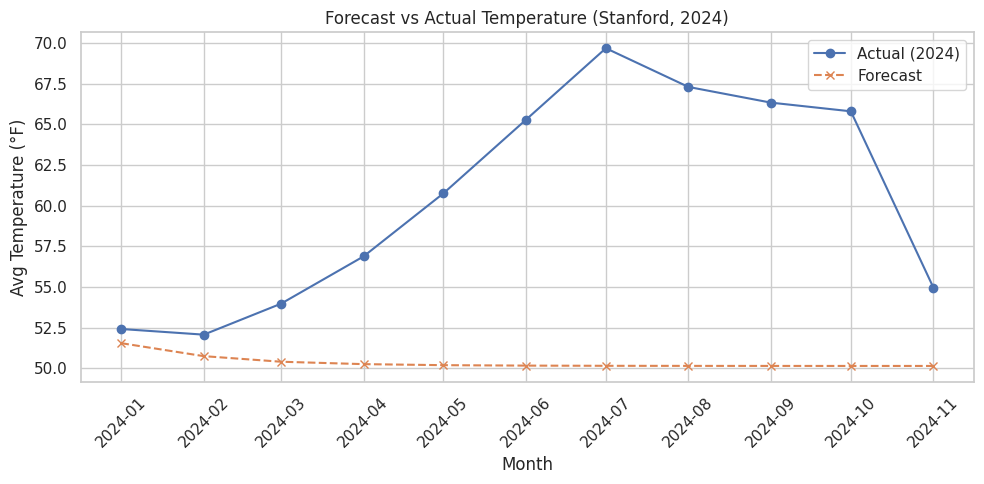

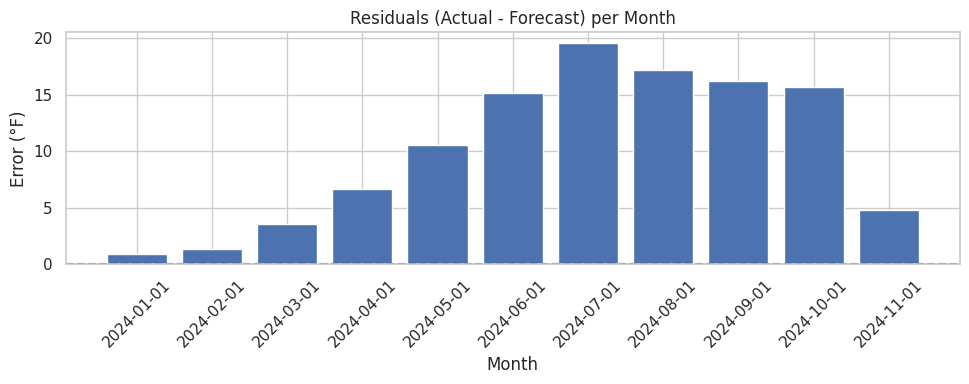

In [ ]:
plot_dif(val, arima_forecast)

### SARIMA

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import numpy as np

# Fit SARIMA model (P, D, Q, s) with s=12 for yearly seasonality
sarima_model = SARIMAX(train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
sarima_result = sarima_model.fit(disp=False)

# Forecast 12 months (2024)
sarima_forecast = sarima_result.forecast(steps=len(val))

# Evaluate
sarima_rmse = np.sqrt(mean_squared_error(val, sarima_forecast))
print("SARIMA RMSE on 2024:", round(sarima_rmse, 5))


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


SARIMA RMSE on 2024: 1.3979


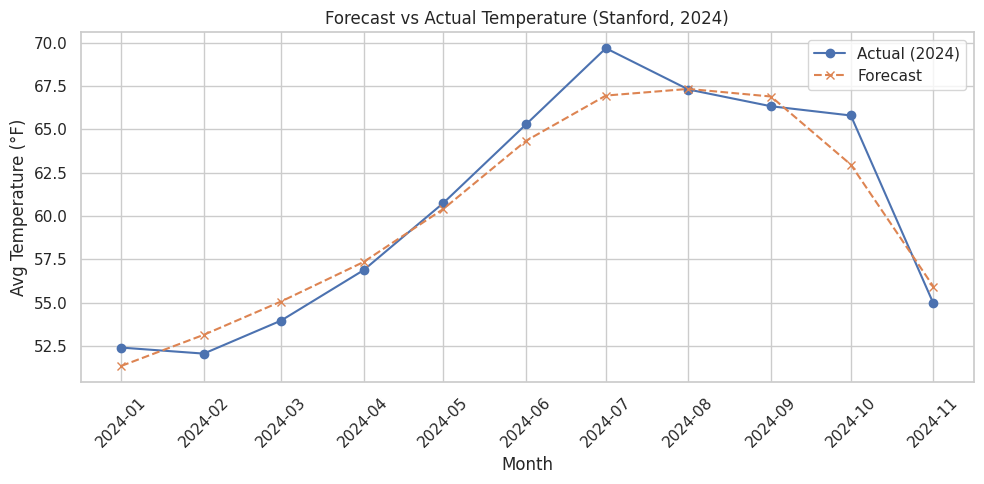

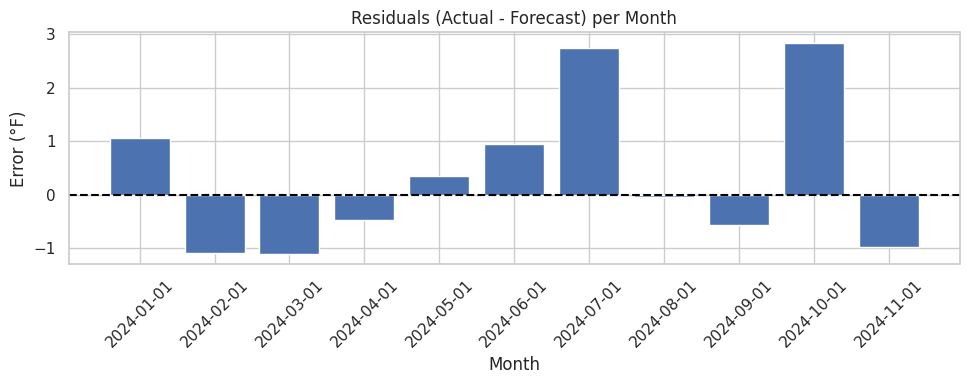

In [ ]:
plot_dif(val, sarima_forecast)

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
import pandas as pd, numpy as np, itertools, warnings

# ------------------ 0) Build Stanford monthly series ------------------
CITY = "Stanford University"
VAL_START = "2024-01-01"
VAL_END   = "2024-11-30"   # month-start stamps (MS)

stan = monthly_summary[monthly_summary['city_name'] == CITY].copy()
# robust to Period/Datetime in 'month'
stan['month'] = stan['month'].dt.to_timestamp() if pd.api.types.is_period_dtype(stan['month']) else pd.to_datetime(stan['month'])
stan = stan.sort_values('month').set_index('month').asfreq('MS')
y = stan['temp'].astype(float).dropna()

# ------------------ 1) Time-series CV helper (expanding window) ------------------
def ts_cv_rmse(y: pd.Series, order, seasonal_order, n_folds=3, val_len=12, min_train=24):
    """
    Expanding-window CV. Each fold trains on data up to fold start, then forecasts `val_len` months ahead.
    Returns mean RMSE across folds.
    """
    y = y.dropna()
    n = len(y)
    # adapt number of folds if series is short
    while n_folds * val_len + min_train > n and n_folds > 0:
        n_folds -= 1
    if n_folds == 0:
        raise ValueError("Not enough history for the requested CV setup.")

    rmses = []
    for k in range(n_folds, 0, -1):
        val_start = n - k * val_len
        tr_end = val_start  # exclusive
        if tr_end < min_train:
            continue
        y_tr = y.iloc[:tr_end]
        y_va = y.iloc[tr_end:tr_end + val_len]
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                mod = SARIMAX(
                    endog=y_tr,
                    order=order,
                    seasonal_order=seasonal_order,
                    enforce_stationarity=False,
                    enforce_invertibility=False,
                )
                res = mod.fit(disp=False)
                fc = res.get_forecast(steps=len(y_va)).predicted_mean
            # align indices
            fc.index = y_va.index
            rmses.append(np.sqrt(mean_squared_error(y_va.values, fc.values)))
        except Exception:
            # if model fails / non-invertible, penalize
            rmses.append(np.inf)
    return float(np.mean(rmses)) if rmses else np.inf

# ------------------ 2) Grid search over a compact SARIMA grid ------------------
S = 12  # monthly seasonality
p_vals = [0,1,2]
d_vals = [1]
q_vals = [0,1,2]
P_vals = [0,1]
D_vals = [1]
Q_vals = [0,1]

param_grid = list(itertools.product(p_vals, d_vals, q_vals, P_vals, D_vals, Q_vals))
best_params = None
best_cv = np.inf

for (p,d,q,P,D,Q) in param_grid:
    cv_rmse = ts_cv_rmse(y, order=(p,d,q), seasonal_order=(P,D,Q,S),
                         n_folds=3, val_len=12, min_train=24)
    print(f"SARIMA order=({p},{d},{q}), seasonal=({P},{D},{Q},{S}) CV RMSE: {cv_rmse:.3f}")
    if cv_rmse < best_cv:
        best_cv = cv_rmse
        best_params = (p,d,q,P,D,Q)

print(f"\nBest CV params: order=({best_params[0]},{best_params[1]},{best_params[2]}), "
      f"seasonal=({best_params[3]},{best_params[4]},{best_params[5]},{S})")
print(f"Mean CV RMSE: {best_cv:.3f}")

# ------------------ 3) Final fit on < VAL_START, evaluate on VAL_START..VAL_END ------------------
train = y.loc[:pd.to_datetime(VAL_START) - pd.offsets.MonthBegin(1)]   # up to 2022-12-01
val   = y.loc[VAL_START:VAL_END]                                       # 2023-01-01 .. 2024-11-01

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    final_mod = SARIMAX(
        endog=train,
        order=(best_params[0], best_params[1], best_params[2]),
        seasonal_order=(best_params[3], best_params[4], best_params[5], S),
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    final_res = final_mod.fit(disp=False)
    final_fc = final_res.get_forecast(steps=len(val)).predicted_mean
    final_fc.index = val.index

final_rmse = np.sqrt(mean_squared_error(val.values, final_fc.values))
print(f"Final SARIMA RMSE on {VAL_START}..{VAL_END}: {final_rmse:.3f}")

# Optional: plot if you have the helper
try:
    plot_dif(val, final_fc)
except NameError:
    pass



NameError: name 'monthly_summary' is not defined

### SARIMA plus dummies for other towns - expanded dataset

In [ ]:
monthly_summary.city_name.unique()

array(['Menlo Park', 'Palo Alto', 'Redwood City', 'Stanford',
       'Stanford University'], dtype=object)

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Assume monthly_summary is already defined
df = monthly_summary.copy()

# Convert month to timestamp (if it's Period)
df['month'] = df['month'].dt.to_timestamp()
df = df.sort_values('month')

# Add intercept and one-hot encode city (drop Stanford University for baseline)
df['intercept'] = 1.0

# Explicitly set Stanford University as baseline
df['city_name'] = pd.Categorical(df['city_name'])
df['city_name'] = df['city_name'].cat.reorder_categories(
    ['Stanford University', 'Menlo Park', 'Palo Alto', 'Redwood City', 'Stanford'],
    ordered=False
)
df = pd.get_dummies(df, columns=['city_name'], drop_first=True)

# Get list of dummy columns (should NOT include Stanford University)
city_dummies = [col for col in df.columns if col.startswith('city_name_')]

# Define train and validation
train_df = df[df['month'] < '2024-01']
val_df = df[(df['month'] >= '2024-01') & (df['month'] <= '2024-11')]

# Keep only Stanford University rows in validation set
val_df = val_df[(val_df[city_dummies].sum(axis=1) == 0)]


# Set datetime index and sort (required for SARIMAX)
train_df = train_df.set_index('month').sort_index()
val_df = val_df.set_index('month').sort_index()

train_df.index = pd.PeriodIndex(train_df.index, freq='M').to_timestamp()
val_df.index = pd.PeriodIndex(val_df.index, freq='M').to_timestamp()

# Define targets and features after fixing index
y_train = train_df['temp']
X_train = train_df[['intercept'] + city_dummies]

y_val = val_df['temp']
X_val = val_df[['intercept'] + city_dummies]

# Ensure float dtype to avoid object errors
X_train = X_train.astype('float32')
X_val = X_val.astype('float32')
y_train = y_train.astype('float32')
y_val = y_val.astype('float32')

In [ ]:
X_train

,intercept,city_name_Menlo Park,city_name_Palo Alto,city_name_Redwood City,city_name_Stanford
month,,,,,
1980-01-01,1.0,1.0,0.0,0.0,0.0
1980-01-01,1.0,0.0,0.0,1.0,0.0
1980-01-01,1.0,0.0,0.0,0.0,1.0
1980-01-01,1.0,0.0,0.0,0.0,0.0
1980-01-01,1.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...
2023-12-01,1.0,0.0,0.0,0.0,1.0
2023-12-01,1.0,0.0,0.0,0.0,0.0
2023-12-01,1.0,0.0,1.0,0.0,0.0


In [ ]:
# Fit SARIMAX
model = SARIMAX(
    endog=y_train,
    exog=X_train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
results = model.fit(disp=False)

# Forecast
forecast = results.forecast(steps=len(y_val), exog=X_val)
forecast.index = y_val.index  # to match for plotting and evaluation

# Evaluate
rmse = np.sqrt(mean_squared_error(y_val, forecast))
print("SARIMAX + city dummies RMSE:", round(rmse, 2))


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


SARIMAX + city dummies RMSE: 8.56


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [ ]:
rmse

np.float64(8.5601596012731)

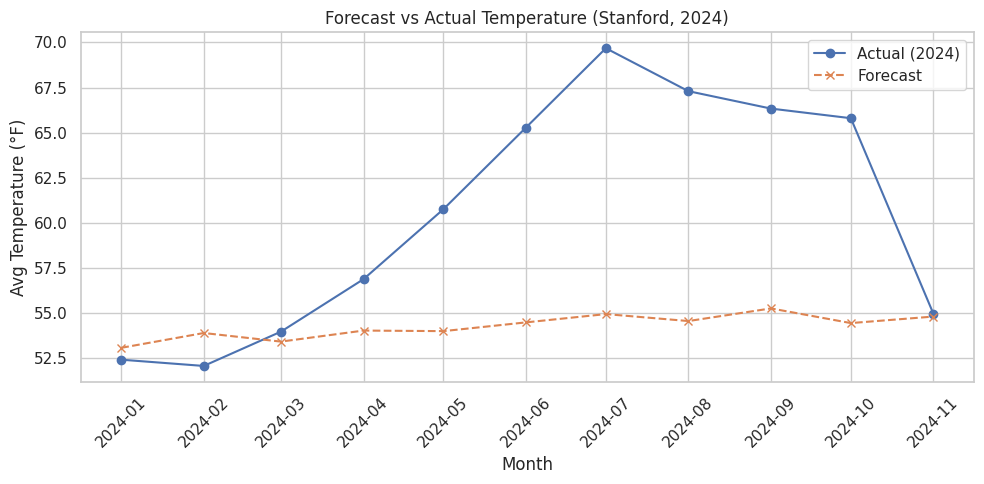

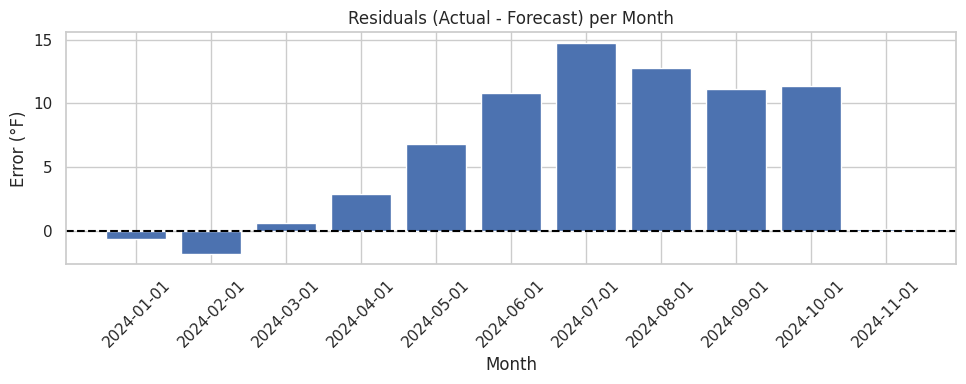

In [ ]:
plot_dif(val, forecast)


### Ensemble SARIMA

Ensemble SARIMA RMSE on Stanford: 1.48306


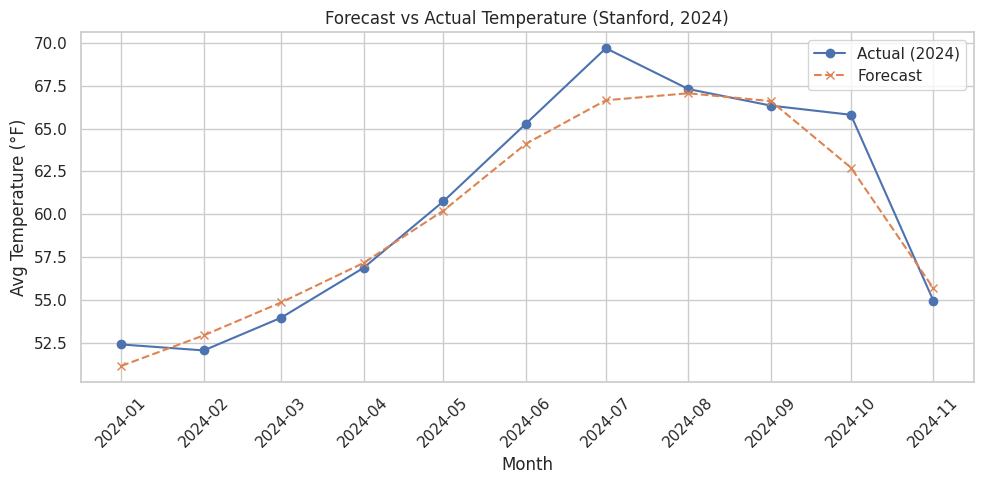

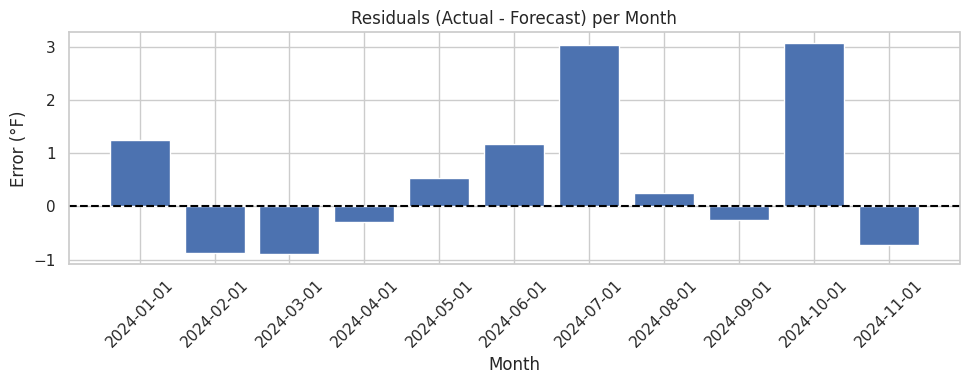

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error

# Load and prep
df = monthly_summary.copy()
df['month'] = df['month'].dt.to_timestamp()
df = df.sort_values('month')

# Set forecast range
forecast_start = '2024-01-01'
forecast_end = '2024-11-30'
n_forecast_months = pd.date_range(start=forecast_start, end=forecast_end, freq='MS').shape[0]

# List of cities
cities = df['city_name'].unique()

# Container for forecasts
city_forecasts = {}
city_rmses = {}

# Loop through each city, train on its full history, forecast into Stanford’s validation period
for city in cities:
    city_df = df[df['city_name'] == city].copy()
    city_df = city_df.set_index('month').sort_index()

    # Force monthly frequency
    city_df = city_df.asfreq('MS')
    city_df = city_df.dropna(subset=['temp'])

    # Train-validation split
    train_series = city_df[city_df.index < forecast_start]['temp']

    # Fit SARIMA on this city's history
    model = SARIMAX(train_series, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12),
                    enforce_stationarity=False, enforce_invertibility=False)
    results = model.fit(disp=False)

    # Forecast n months into Stanford’s future
    forecast = results.get_forecast(steps=n_forecast_months).predicted_mean
    forecast.index = pd.date_range(start=forecast_start, periods=n_forecast_months, freq='MS')

    city_forecasts[city] = forecast
    # Optional: Evaluate on Stanford if you want to see which city matches best
    stanford_val = df[(df['city_name'] == 'Stanford University') &
                      (df['month'] >= forecast_start) &
                      (df['month'] <= forecast_end)].copy()
    stanford_val = stanford_val.set_index('month').sort_index().asfreq('MS')
    rmse = np.sqrt(mean_squared_error(stanford_val['temp'], forecast))
    city_rmses[city] = rmse

# Build weighted average forecast (inverse-RMSE weighting)
rmse_series = pd.Series(city_rmses)
inv_rmse_weights = 1 / rmse_series
normalized_weights = inv_rmse_weights / inv_rmse_weights.sum()

# Final ensemble forecast
ensemble_forecast = sum(normalized_weights[city] * city_forecasts[city] for city in cities)

# Final evaluation
true_vals = df[(df['city_name'] == 'Stanford University') &
               (df['month'] >= forecast_start) &
               (df['month'] <= forecast_end)]['temp'].values
rmse_ensemble = np.sqrt(mean_squared_error(true_vals, ensemble_forecast))
print("Ensemble SARIMA RMSE on Stanford:", round(rmse_ensemble, 5))

# Plot
plot_dif(val, ensemble_forecast)


## XGBoost / Random Forest

### Only temperature (SU only)

In [ ]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

# --- features (only what we use) ---
def create_features(df):
    df = df.copy()
    df['month_num'] = df.index.month
    df['year'] = df.index.year
    df['lag1'] = df['temp'].shift(1)     # TRAIN will use these true lags
    df['lag12'] = df['temp'].shift(12)
    return df

# --- data (Stanford only) ---
df = monthly_summary[monthly_summary['city_name'] == 'Stanford University'].copy()
df['month'] = df['month'].dt.to_timestamp()
df = df.set_index('month').sort_index()

df = create_features(df)

# --- splits ---
train = df[df.index < '2024-01-01'].copy()
val   = df[(df.index >= '2024-01-01') & (df.index <= '2024-11-30')].copy()

# TRAIN: drop early NaNs from lags, use true lags (ok, they’re historical)
train = train.dropna(subset=['lag1','lag12'])
feat_cols = ['month_num','year','lag1','lag12']
X_train = train[feat_cols]
y_train = train['temp']

# VAL: keep ONLY static time features + target (for scoring); DROP lag columns to avoid any chance of peeking
val = val.drop(columns=['lag1','lag12'], errors='ignore')
y_val = val['temp']
# we’ll read month_num/year from val, and build lag1/lag12 from our own rolling predictions

# --- fit ---
model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

# --- CLOSED-LOOP prediction (no leakage) ---
preds = []
hist = y_train.sort_index().copy()  # seed with train actuals only

for ts in val.index:  # sequential months in 2023-01 .. 2024-11
    row = pd.DataFrame({
        'month_num': [val.at[ts, 'month_num']],
        'year':      [val.at[ts, 'year']],
        # lags are rebuilt from our history (train actuals + prior predictions)
        'lag1':      [hist.iloc[-1]],
        'lag12':     [hist.iloc[-12] if len(hist) >= 12 else hist.iloc[-1]],
    }, index=[ts])

    yhat = float(model.predict(row))
    preds.append(yhat)
    hist.loc[ts] = yhat  # update history so next step uses this as lag

preds = pd.Series(preds, index=val.index)

# --- evaluate ---
rmse = float(np.sqrt(mean_squared_error(y_val, preds)))
print(f"XGBoost (closed-loop, no leakage) RMSE: {rmse:.3f}")



XGBoost (closed-loop, no leakage) RMSE: 1.850


/tmp/ipython-input-2064118881.py:54: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  yhat = float(model.predict(row))
/tmp/ipython-input-2064118881.py:54: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  yhat = float(model.predict(row))
/tmp/ipython-input-2064118881.py:54: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  yhat = float(model.predict(row))
/tmp/ipython-input-2064118881.py:54: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, 

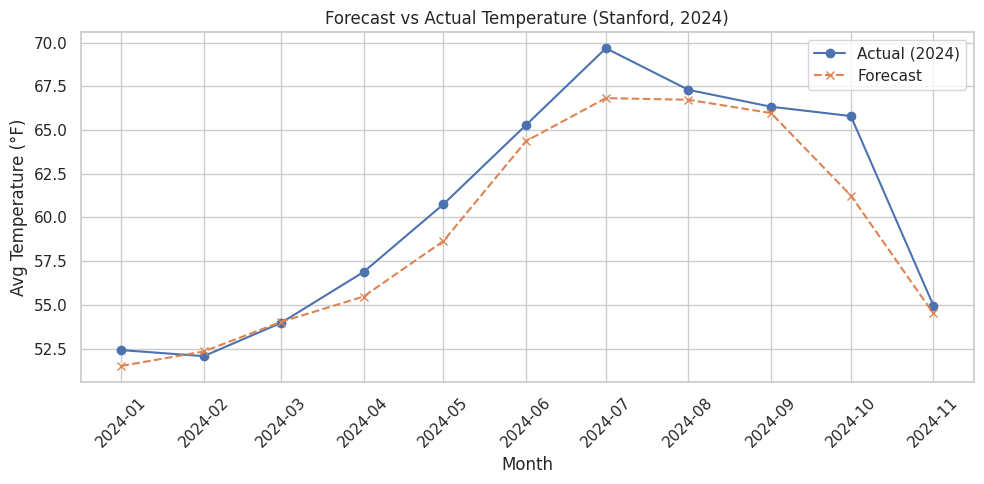

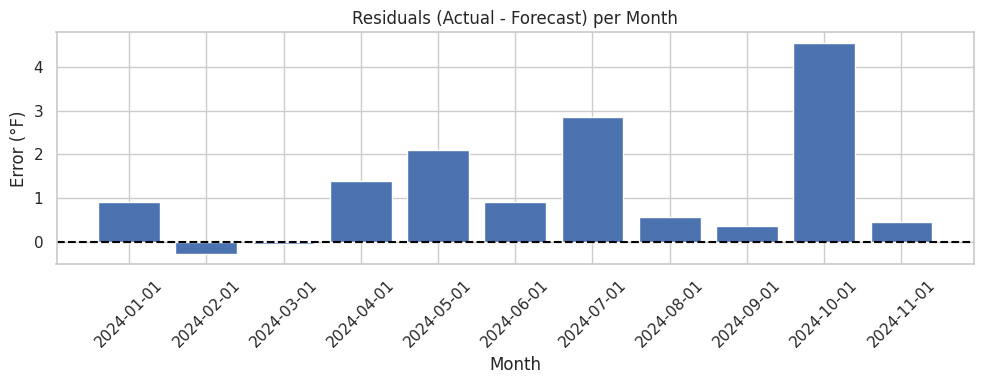

In [ ]:
plot_dif(y_val, pd.Series(preds, index=y_val.index))

### XGBoost with covariates predicted using SARIMA (Stanford only)



In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import pandas as pd, numpy as np

# --- CONFIG --- #
covariates = ['dew_point', 'wind_deg', 'pressure', 'rain_hours']
VAL_START = '2024-01-01'
VAL_END   = '2024-11-30'
TARGET_CITY = 'Stanford University'

# --- Prep data --- #
df = monthly_summary.copy()
df['month'] = df['month'].dt.to_timestamp()
df = df.sort_values('month').set_index('month')

# Save original_city for masking
df['original_city'] = df['city_name']

# Add calendar and lag features. `create_features` should be defined previously.
df = create_features(df)

# Define feature columns for the XGBoost model
feature_cols = [
    'month_num',
    'year',
    'lag1',
    'lag12',
] + covariates

# Filter to only Stanford University data for X and y
X_all = df[df['original_city'] == TARGET_CITY][feature_cols].copy()
y_all = df[df['original_city'] == TARGET_CITY]['temp'].copy()

# Cast covariates to float to avoid potential type issues
for cov in covariates:
    if cov in X_all.columns:
        X_all[cov] = pd.to_numeric(X_all[cov], errors='coerce').astype(float)

# --- Train / Val split --- #
X_train = X_all[X_all.index < VAL_START].copy()
y_train = y_all[y_all.index < VAL_START].copy()

val_mask = (X_all.index >= VAL_START) & (X_all.index <= VAL_END)
X_val = X_all.loc[val_mask].copy()
y_val = y_all.loc[val_mask].copy()

# --- Inject SARIMA-forecasted covariates into X_val --- #
# cov_forecasts should be a DataFrame with date index and covariate columns
cf = cov_forecasts.copy()
# Ensure cov_forecasts index is datetime and matches frequency
cf.index = cf.index.to_timestamp() if pd.api.types.is_period_dtype(cf.index) else pd.to_datetime(cf.index)
cf = cf.sort_index().asfreq('MS')

for cov in covariates:
    if cov in X_val.columns and cov in cf.columns:
        X_val.loc[:, cov] = pd.to_numeric(cf.reindex(X_val.index)[cov], errors='coerce').astype(float).values

# --- Clean train rows with NaN lags --- #
good_train = ~X_train[['lag1','lag12']].isnull().any(axis=1) & y_train.notnull()
X_train, y_train = X_train.loc[good_train], y_train.loc[good_train]

# --- Train XGBoost model --- #
model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

# --- CLOSED-LOOP prediction (no leakage for lags) --- #
preds = []
hist = y_train.sort_index().copy()  # Seed with training actuals only

# Prepare X_val_base without lags to rebuild them iteratively
X_val_base = X_val.drop(columns=['lag1', 'lag12'], errors='ignore').copy()

for ts in X_val_base.index:
    row = X_val_base.loc[[ts]].copy()
    # Rebuild lags from our own rolling history (training actuals + prior predictions)
    row['lag1']  = hist.iloc[-1]
    row['lag12'] = hist.iloc[-12] if len(hist) >= 12 else hist.iloc[-1] # Fallback if not enough history

    # Ensure column order matches training data
    row = row.reindex(columns=X_train.columns)

    yhat = float(model.predict(row))
    preds.append(yhat)
    hist.loc[ts] = yhat  # Update history with current prediction

preds = pd.Series(preds, index=X_val_base.index)

# --- Evaluate --- #
rmse = float(np.sqrt(mean_squared_error(y_val, preds)))
print(f"XGBoost with SARIMA-predicted covariates RMSE (Stanford only): {rmse:.3f}")

# --- Plot --- #
# plot_dif function is assumed to be defined earlier in the notebook
plot_dif(y_val, preds)

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pandas as pd
import numpy as np

covariates = ['dew_point', 'wind_deg', 'pressure', 'rain_hours']

def get_covariates_forecast(df, covariates):
  # Define train + forecast ranges
  train_df = df[df.index < '2024-01-01']
  train_df = train_df[train_df['city_name'] == "Stanford University"]

  # Forecast range
  forecast_index = pd.date_range('2024-01-01', '2024-11-30', freq='MS')

  # Store forecasts here
  cov_forecasts = pd.DataFrame(index=forecast_index)

  # Fit SARIMA model and forecast each covariate
  for cov in covariates:
      y = train_df[cov].dropna()

      # Fit a simple SARIMA model (can tune later)
      model = SARIMAX(y, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12), enforce_stationarity=False, enforce_invertibility=False)
      results = model.fit(disp=False)

      # Forecast for future months
      forecast = results.forecast(steps=len(forecast_index))
      cov_forecasts[cov] = forecast.values

  # Check the result
  return cov_forecasts

cov_forecasts = get_covariates_forecast(df, covariates)
cov_forecasts.head()


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_date

,dew_point,wind_deg,pressure,rain_hours
2024-01-01,44.008774,162.926988,1019.782862,138.007238
2024-02-01,43.481138,190.677251,1018.427375,135.491644
2024-03-01,45.161852,203.185537,1017.965669,138.268797
2024-04-01,46.372033,223.348666,1017.494218,77.386265
2024-05-01,49.540957,227.195985,1015.744901,46.620813


In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import pandas as pd, numpy as np

covariates = ['dew_point', 'wind_deg', 'pressure', 'rain_hours']

# Prep data
df = monthly_summary.copy()
df['month'] = df['month'].dt.to_timestamp()
df = df.sort_values('month').set_index('month')
df['original_city'] = df['city_name']

# Features (lags are fine in TRAIN; we won't use val lags)
df = create_features(df)

feature_cols = [
    'dew_point','wind_deg','pressure','rain_hours',
    'month_num','year','lag1','lag12'
]

X = df[feature_cols].copy()
y = df['temp'].copy()

# Train / Val split
X_train = X[X.index < '2024-01-01'].copy()
y_train = y[y.index < '2024-01-01'].copy()

val_mask = (df['original_city'] == 'Stanford University') & \
           (df.index >= '2024-01-01') & (df.index <= '2024-11-30')

# Build X_val_base WITHOUT lag1/lag12
X_val_base = X[val_mask].copy().drop(columns=['lag1','lag12'], errors='ignore')
y_val = y[val_mask].copy()

# Inject SARIMA covariate forecasts (aligned, float)
cf = cov_forecasts.copy()
cf.index = pd.to_datetime(cf.index).to_period('M').to_timestamp()
for cov in covariates:
    X_val_base.loc[:, cov] = pd.to_numeric(cf.reindex(X_val_base.index)[cov], errors='coerce').astype(float).values

# Clean train rows with lag NaNs
good_train = ~X_train[['lag1','lag12']].isnull().any(axis=1) & y_train.notnull()
X_train, y_train = X_train.loc[good_train], y_train.loc[good_train]

# Train model
model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

# CLOSED-LOOP prediction: add lags from rolling history at inference time
preds = []
hist = y_train.sort_index().copy()

for ts in X_val_base.index:
    row = X_val_base.loc[[ts]].copy()
    row['lag1']  = hist.iloc[-1]
    row['lag12'] = hist.iloc[-12] if len(hist) >= 12 else hist.iloc[-1]
    # ensure column order matches training
    row = row.reindex(columns=X_train.columns)
    yhat = float(model.predict(row))
    preds.append(yhat)
    hist.loc[ts] = yhat

preds = pd.Series(preds, index=X_val_base.index)

rmse = float(np.sqrt(mean_squared_error(y_val, preds)))
print("XGBoost RMSE (closed-loop, no lag leakage):", round(rmse, 3))


/tmp/ipython-input-1336962691.py:39: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[138.00723759 135.4916439  138.26879721  77.38626463  46.62081297
  18.68100563  11.98012669  12.34939919  21.30713002  44.28521228
  83.33999405]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_val_base.loc[:, cov] = pd.to_numeric(cf.reindex(X_val_base.index)[cov], errors='coerce').astype(float).values


XGBoost RMSE (closed-loop, no lag leakage): 2.205


/tmp/ipython-input-1336962691.py:59: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  yhat = float(model.predict(row))
/tmp/ipython-input-1336962691.py:59: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  yhat = float(model.predict(row))
/tmp/ipython-input-1336962691.py:59: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  yhat = float(model.predict(row))
/tmp/ipython-input-1336962691.py:59: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, 

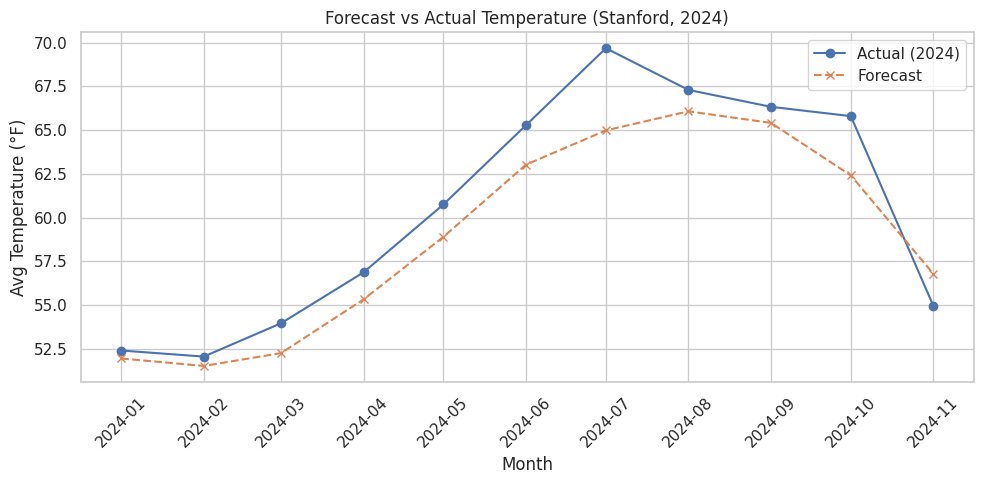

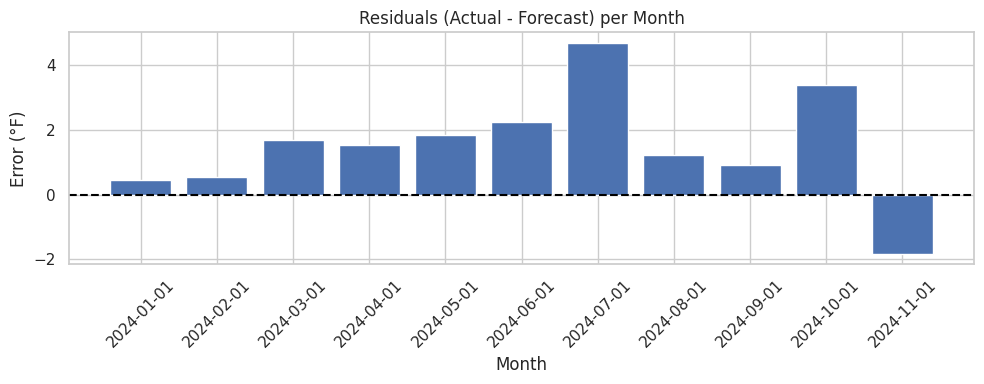

In [ ]:
plot_dif(y_val, pd.Series(preds, index=y_val.index))

### XGBoost with dummies + covariates (all towns)

In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import pandas as pd, numpy as np

covariates = ['dew_point', 'wind_deg', 'pressure', 'rain_hours']

# Prep data
df = monthly_summary.copy()
df['month'] = df['month'].dt.to_timestamp()
df = df.sort_values('month').set_index('month')

# Save original city_name for validation mask
df['original_city'] = df['city_name']

# One-hot encode city
df = pd.get_dummies(df, columns=['city_name'], drop_first=False)

# Create features (must use past-only shifts inside this function)
df = create_features(df)

# Select features
additional_features = [
    'dew_point', 'wind_deg', 'pressure', 'rain_hours',
    'month_num', 'year', 'lag1', 'lag12'
] + [col for col in df.columns if col.startswith('city_name_')]

X = df[additional_features].copy()
y = df['temp'].copy()

# Train/Val Split
X_train = X[X.index < '2024-01-01'].copy()
y_train = y[y.index < '2024-01-01'].copy()

val_mask = (df['original_city'] == 'Stanford University') & \
           (df.index >= '2024-01-01') & (df.index <= '2024-11-30')

# Build X_val WITHOUT lag1/lag12 to avoid peeking
X_val = X[val_mask].copy().drop(columns=['lag1','lag12'], errors='ignore')
y_val = y[val_mask].copy()

# Overwrite validation covariates with SARIMA forecasts (aligned, float)
cf = cov_forecasts.copy()
cf.index = pd.to_datetime(cf.index).to_period('M').to_timestamp()
cf = cf.sort_index()
for cov in covariates:
    X_val.loc[:, cov] = pd.to_numeric(cf.reindex(X_val.index)[cov], errors='coerce').astype(float).values

# Clean train rows with lag NaNs (from early shifts)
good_train = ~X_train[['lag1','lag12']].isnull().any(axis=1) & y_train.notnull()
X_train, y_train = X_train.loc[good_train], y_train.loc[good_train]

# Train model
model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

# -------- CLOSED-LOOP PREDICTION (rebuild lags from our own history) --------
preds = []
hist = y_train.sort_index().copy()  # seed with training actuals

for ts in X_val.index:  # sequential months in 2023-01 .. 2024-11
    row = X_val.loc[[ts]].copy()
    # inject lags from rolling history (no true val lags)
    row['lag1']  = hist.iloc[-1]
    row['lag12'] = hist.iloc[-12] if len(hist) >= 12 else hist.iloc[-1]
    # ensure same column order as training
    row = row.reindex(columns=X_train.columns)
    yhat = float(model.predict(row))
    preds.append(yhat)
    hist.loc[ts] = yhat  # update history for next step

preds = pd.Series(preds, index=X_val.index)

# Evaluate
rmse = float(np.sqrt(mean_squared_error(y_val, preds)))
print("XGBoost RMSE (closed-loop, no lag leakage):", round(rmse, 3))




/tmp/ipython-input-2006780890.py:46: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[138.00723759 135.4916439  138.26879721  77.38626463  46.62081297
  18.68100563  11.98012669  12.34939919  21.30713002  44.28521228
  83.33999405]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_val.loc[:, cov] = pd.to_numeric(cf.reindex(X_val.index)[cov], errors='coerce').astype(float).values
/tmp/ipython-input-2006780890.py:67: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  yhat = float(model.predict(row))
/tmp/ipython-input-2006780890.py:67: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before perform

XGBoost RMSE (closed-loop, no lag leakage): 2.059


/tmp/ipython-input-2006780890.py:67: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  yhat = float(model.predict(row))


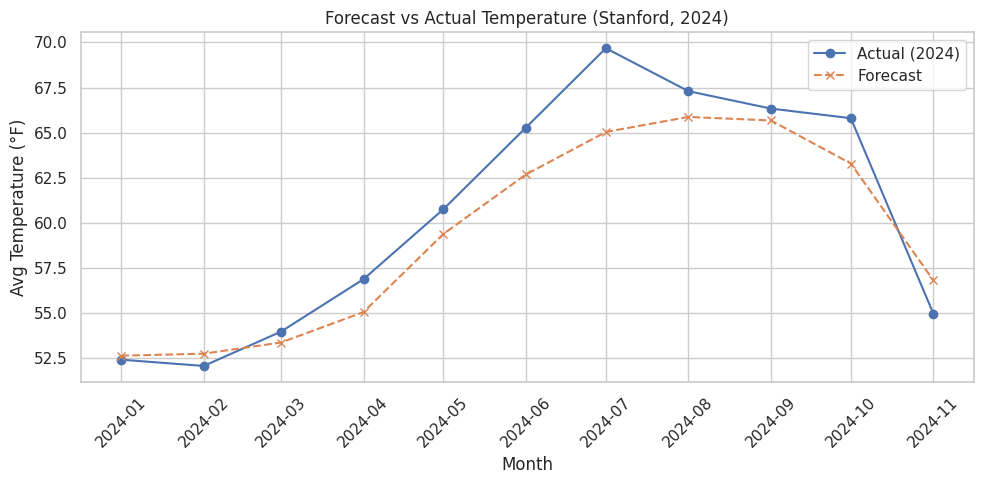

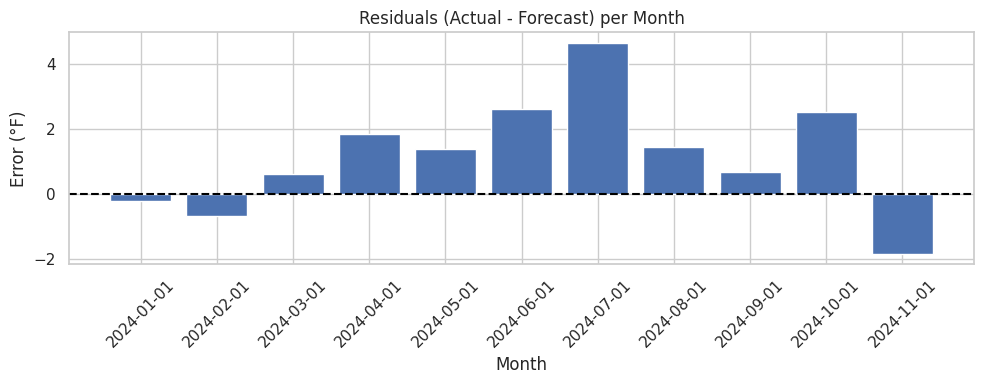

In [ ]:
plot_dif(y_val, pd.Series(preds, index=y_val.index))

/tmp/ipython-input-4228543984.py:51: DeprecationWarning: is_period_dtype is deprecated and will be removed in a future version. Use `isinstance(dtype, pd.PeriodDtype)` instead
  cf.index = cf.index.to_timestamp() if pd.api.types.is_period_dtype(cf.index) else pd.to_datetime(cf.index)
/tmp/ipython-input-4228543984.py:84: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  yhat = float(model.predict(row))
/tmp/ipython-input-4228543984.py:84: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  yhat = float(model.predict(row))
/tmp/ipython-input-4228543984.py:84: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will

Params lr=0.03, depth=3, n=600 -> Closed-loop RMSE: 2.162


/tmp/ipython-input-4228543984.py:84: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  yhat = float(model.predict(row))
/tmp/ipython-input-4228543984.py:84: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  yhat = float(model.predict(row))
/tmp/ipython-input-4228543984.py:84: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  yhat = float(model.predict(row))
/tmp/ipython-input-4228543984.py:84: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, 

Params lr=0.03, depth=3, n=900 -> Closed-loop RMSE: 2.059


/tmp/ipython-input-4228543984.py:84: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  yhat = float(model.predict(row))
/tmp/ipython-input-4228543984.py:84: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  yhat = float(model.predict(row))
/tmp/ipython-input-4228543984.py:84: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  yhat = float(model.predict(row))
/tmp/ipython-input-4228543984.py:84: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, 

...

/tmp/ipython-input-4228543984.py:84: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  yhat = float(model.predict(row))
/tmp/ipython-input-4228543984.py:84: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  yhat = float(model.predict(row))
/tmp/ipython-input-4228543984.py:84: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  yhat = float(model.predict(row))
/tmp/ipython-input-4228543984.py:84: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, 

Params lr=0.1, depth=5, n=900 -> Closed-loop RMSE: 1.930


/tmp/ipython-input-4228543984.py:84: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  yhat = float(model.predict(row))
/tmp/ipython-input-4228543984.py:84: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  yhat = float(model.predict(row))
/tmp/ipython-input-4228543984.py:84: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  yhat = float(model.predict(row))
/tmp/ipython-input-4228543984.py:84: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, 

Params lr=0.1, depth=5, n=1200 -> Closed-loop RMSE: 1.941

Best params: learning_rate=0.03, max_depth=4, n_estimators=1200
Best closed-loop RMSE (no lag leakage): 1.909


/tmp/ipython-input-4228543984.py:84: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  yhat = float(model.predict(row))
/tmp/ipython-input-4228543984.py:84: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  yhat = float(model.predict(row))
/tmp/ipython-input-4228543984.py:84: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  yhat = float(model.predict(row))
/tmp/ipython-input-4228543984.py:84: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, 

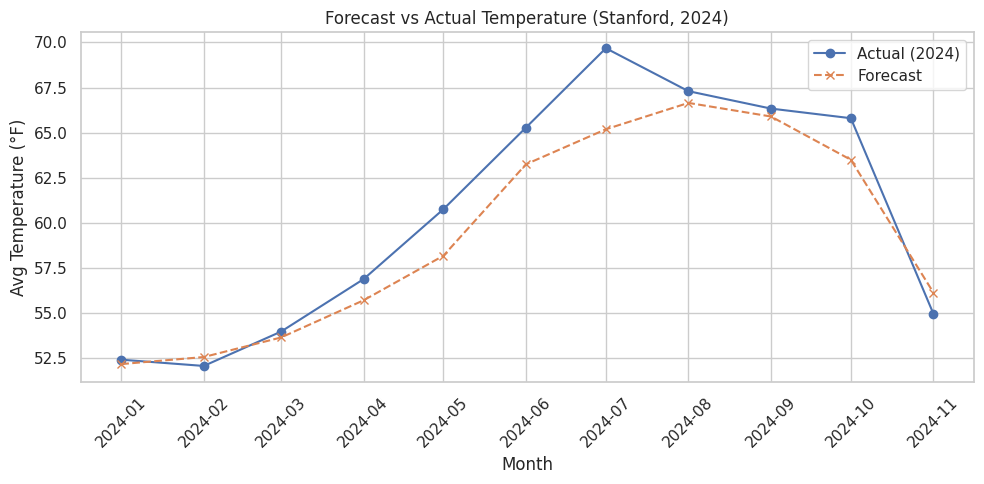

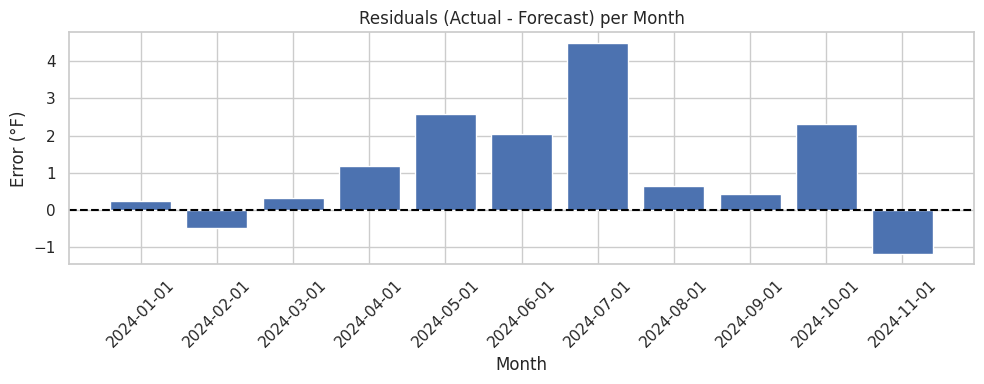

In [ ]:
# @title
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd
import itertools

# ---------------- Config ----------------
covariates = ['dew_point', 'wind_deg', 'pressure', 'rain_hours']  # must exist in X and cov_forecasts
VAL_START, VAL_END = '2024-01-01', '2024-11-30'
TARGET_CITY = 'Stanford University'

# ---------------- Prep data ----------------
df = monthly_summary.copy()
df['month'] = df['month'].dt.to_timestamp()
df = df.sort_values('month').set_index('month')

df['original_city'] = df['city_name']
df = pd.get_dummies(df, columns=['city_name'], drop_first=False)

# Must create month_num, year, lag1, lag12 using only past (shift) inside this function
df = create_features(df)

# Feature set (keep it like your original)
feature_cols = [
    'dew_point','wind_deg','pressure','rain_hours',
    'month_num','year','lag1','lag12'
] + [c for c in df.columns if c.startswith('city_name_')]

X_all = df[feature_cols].copy()
y_all = df['temp'].copy()

# Cast covariates to float (avoids dtype warnings)
for cov in covariates:
    if cov in X_all.columns:
        X_all[cov] = pd.to_numeric(X_all[cov], errors='coerce').astype(float)

# ---------------- Train / Val split ----------------
X_train = X_all[X_all.index < VAL_START].copy()
y_train = y_all[y_all.index < VAL_START].copy()

val_mask = (
    (df['original_city'] == TARGET_CITY) &
    (df.index >= VAL_START) & (df.index <= VAL_END)
)
X_val_full = X_all[val_mask].copy()
y_val = y_all[val_mask].copy()

# ---------------- Inject forecasted covariates (no leakage) ----------------
cf = cov_forecasts.copy()
# normalize cov_forecasts index to month-start
cf.index = cf.index.to_timestamp() if pd.api.types.is_period_dtype(cf.index) else pd.to_datetime(cf.index)
cf = cf.sort_index().asfreq('MS')

for cov in covariates:
    if cov in X_val_full.columns and cov in cf.columns:
        X_val_full.loc[:, cov] = pd.to_numeric(cf.reindex(X_val_full.index)[cov], errors='coerce').astype(float).values

# ---------------- Clean train & make a val base WITHOUT lags ----------------
# drop early NaNs from train lags
good_train = y_train.notnull() & (~X_train[['lag1','lag12']].isnull().any(axis=1))
X_train = X_train.loc[good_train].copy()
y_train = y_train.loc[good_train].copy()

# X_val base: remove lag columns so we can't peek at true lags
X_val_base = X_val_full.drop(columns=['lag1','lag12'], errors='ignore').copy()

# Ensure non-lag columns exist in the same order as training (we'll add lags on the fly)
nonlag_cols_train = [c for c in X_train.columns if c not in ['lag1','lag12']]
X_val_base = X_val_base.reindex(columns=nonlag_cols_train, fill_value=0.0)

# ---------------- Closed-loop predictor (rebuild lags from our own preds) ----------------
def closed_loop_predict(model, X_train_cols, X_val_base, y_train_hist):
    preds = []
    hist = y_train_hist.sort_index().copy()  # seed with train actuals
    for ts in X_val_base.index:
        row = X_val_base.loc[[ts]].copy()
        # rebuild lags from rolling history (no true val lags)
        lag1  = hist.iloc[-1] if len(hist) >= 1 else hist.mean()
        lag12 = hist.iloc[-12] if len(hist) >= 12 else lag1
        row['lag1']  = lag1
        row['lag12'] = lag12
        # exact training column order
        row = row.reindex(columns=X_train_cols, fill_value=0.0)
        yhat = float(model.predict(row))
        preds.append(yhat)
        hist.loc[ts] = yhat
    return pd.Series(preds, index=X_val_base.index)

# ---------------- Simple 36-combo grid (≈30–40 models) ----------------
# 4 * 3 * 3 = 36
grid = list(itertools.product(
    [0.03, 0.05, 0.07, 0.10],   # learning_rate
    [3, 4, 5],                  # max_depth
    [600, 900, 1200],           # n_estimators
))
best_params, best_rmse = None, np.inf

for lr, md, ne in grid:
    model = XGBRegressor(
        learning_rate=lr,
        max_depth=md,
        n_estimators=ne,
        min_child_weight=3,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
    )
    model.fit(X_train, y_train)
    preds = closed_loop_predict(model, X_train.columns, X_val_base, y_train)
    rmse = float(np.sqrt(mean_squared_error(y_val.loc[preds.index], preds.values)))
    print(f"Params lr={lr}, depth={md}, n={ne} -> Closed-loop RMSE: {rmse:.3f}")
    if rmse < best_rmse:
        best_rmse, best_params = rmse, (lr, md, ne)

print(f"\nBest params: learning_rate={best_params[0]}, max_depth={best_params[1]}, n_estimators={best_params[2]}")
print(f"Best closed-loop RMSE (no lag leakage): {best_rmse:.3f}")

# ---------------- Optional: refit best & plot ----------------
best_model = XGBRegressor(
    learning_rate=best_params[0],
    max_depth=best_params[1],
    n_estimators=best_params[2],
    min_child_weight=3,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
).fit(X_train, y_train)

best_preds = closed_loop_predict(best_model, X_train.columns, X_val_base, y_train)

try:
    plot_dif(y_val, best_preds)
except NameError:
    pass




### XGBoost with covariates predicted using XGBOOST (all towns)


/tmp/ipython-input-355913097.py:62: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  yhat = float(model.predict(X_f))
/tmp/ipython-input-355913097.py:62: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  yhat = float(model.predict(X_f))
/tmp/ipython-input-355913097.py:62: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  yhat = float(model.predict(X_f))
/tmp/ipython-input-355913097.py:62: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and 

XGBoost RMSE (XGB-forecasted regs, CLOSED-LOOP, 2024-01-01..2024-11-30): 2.424


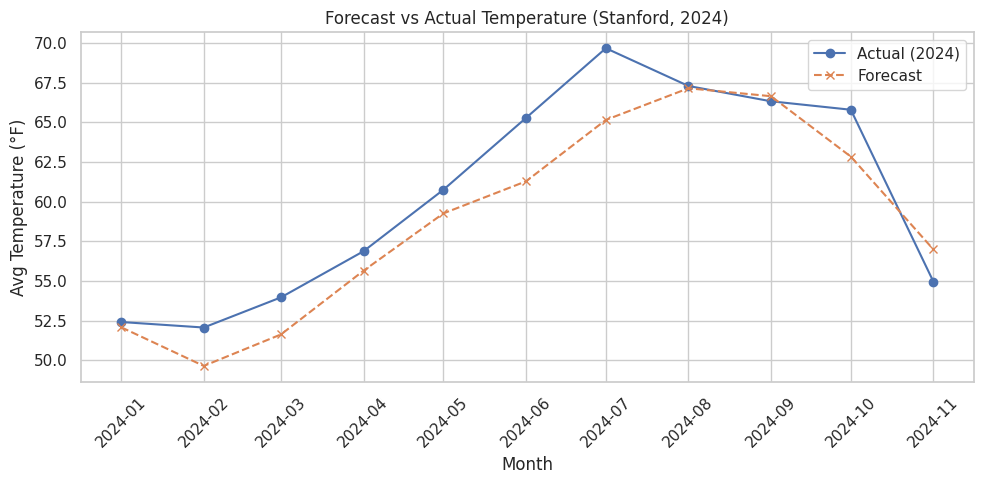

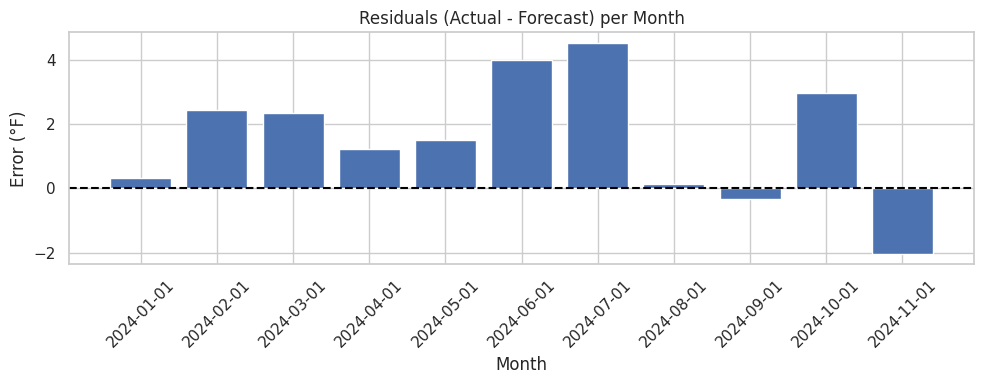

In [ ]:
# === End-to-end: XGB-forecasted regressors -> main XGBoost temp model (closed-loop, no leakage) ===
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import pandas as pd, numpy as np

# --------------------------------------------------------------------------------------
# 0) CONFIG
# --------------------------------------------------------------------------------------
REGS = ['pressure', 'dew_point', 'humidity', 'rain_hours', 'snow_hours']  # desired regressors
TARGET_CITY = 'Stanford University'

TRAIN_END = '2023-12-31'      # train < 2023-01-01
VAL_START = '2024-01-01'
VAL_END   = '2024-11-30'
VAL_CAL   = pd.date_range(VAL_START, '2024-11-01', freq='MS')  # month-start stamps

# --------------------------------------------------------------------------------------
# 1) UTILITIES: calendar feats + regressor forecaster (XGBoost)
# --------------------------------------------------------------------------------------
def _add_calendar_feats(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["month"] = df["ds"].dt.month
    df["sin12"] = np.sin(2*np.pi*df["month"]/12.0)
    df["cos12"] = np.cos(2*np.pi*df["month"]/12.0)
    return df

def forecast_covariates_xgb(train_regs: pd.DataFrame, regs: list, future_ds: pd.DatetimeIndex) -> pd.DataFrame:
    """
    train_regs: DataFrame(['ds'] + regs), pre-2023 monthly history for Stanford, sorted by ds
    future_ds:  DatetimeIndex of month-starts for 2023-01-01 .. 2024-11-01
    returns:    DataFrame(['ds'] + regs) of forecasts aligned to future_ds
    """
    out = pd.DataFrame({"ds": pd.to_datetime(future_ds)})
    tr = train_regs.copy().sort_values("ds")
    for r in regs:
        if r not in tr.columns:
            continue
        s = tr[["ds", r]].dropna().copy()
        s["lag1"]  = s[r].shift(1)
        s["lag12"] = s[r].shift(12)
        s = s.dropna()

        feats = _add_calendar_feats(s[["ds"]])
        X_tr  = pd.concat([feats[["month","sin12","cos12"]].reset_index(drop=True),
                           s[["lag1","lag12"]].reset_index(drop=True)], axis=1)
        y_tr  = s[r].reset_index(drop=True)

        model = XGBRegressor(
            n_estimators=400, max_depth=4, learning_rate=0.05,
            subsample=0.9, colsample_bytree=0.9, random_state=42
        )
        model.fit(X_tr, y_tr)

        # Recursive multi-step forecast
        hist = tr.set_index("ds")[r].dropna().copy()
        preds = []
        for ds_ts in out["ds"]:
            lag1  = hist.iloc[-1]
            lag12 = hist.iloc[-12] if len(hist) >= 12 else lag1
            X_f = _add_calendar_feats(pd.DataFrame({"ds":[ds_ts]}))[["month","sin12","cos12"]]
            X_f = pd.concat([X_f, pd.DataFrame({"lag1":[lag1], "lag12":[lag12]})], axis=1)
            yhat = float(model.predict(X_f))
            preds.append(yhat)
            hist.loc[ds_ts] = yhat
        out[r] = preds
    return out

# --------------------------------------------------------------------------------------
# 2) BUILD STANFORD REGRESSOR HISTORY & FORECAST THEM WITH XGB (train-only fit)
# --------------------------------------------------------------------------------------
# Stanford-only monthly regressors (history)
hist_regs = monthly_summary[monthly_summary['city_name'] == TARGET_CITY][['month'] + REGS].copy()
hist_regs['ds'] = pd.to_datetime(hist_regs['month'].dt.to_timestamp())
hist_regs = hist_regs[['ds'] + REGS].sort_values('ds')

# Use only regs that actually exist in your data
REGS_IN_DATA = [r for r in REGS if r in hist_regs.columns]

# Train window for regressor forecasters (pre-2023), with train-only interpolation
train_regs = hist_regs[hist_regs['ds'] < VAL_START].copy()
train_regs[REGS_IN_DATA] = (train_regs[REGS_IN_DATA]
                            .apply(pd.to_numeric, errors='coerce')
                            .interpolate(limit_direction='both'))

# Forecast regressors for validation months (2023-01 .. 2024-11)
pred_regs = forecast_covariates_xgb(train_regs, REGS_IN_DATA, VAL_CAL)

# Safety checks
assert set(['ds'] + REGS_IN_DATA).issubset(set(pred_regs.columns)), "Missing columns in pred_regs."
assert pred_regs[REGS_IN_DATA].isnull().sum().sum() == 0, "NaNs in predicted regressors."

# --------------------------------------------------------------------------------------
# 3) BUILD THE MAIN FEATURE TABLE FROM monthly_summary
# --------------------------------------------------------------------------------------
df = monthly_summary.copy()
df['month'] = df['month'].dt.to_timestamp()
df = df.sort_values('month').set_index('month')

# Keep original city for masking
df['original_city'] = df['city_name']

# One-hot encode cities
df = pd.get_dummies(df, columns=['city_name'], drop_first=False)

# Your feature creator must use past-only shifts for lags
df = create_features(df)  # expected to add month_num, year, lag1, lag12, etc.

# Define features: forecasted regressors + safe time features + city dummies
city_cols = [c for c in df.columns if c.startswith('city_name_')]
feature_cols = REGS_IN_DATA + ['month_num', 'year', 'lag1', 'lag12'] + city_cols
feature_cols = [c for c in feature_cols if c in df.columns]  # just in case

# Keep just these columns plus the target
X_all = df[feature_cols].copy()
y_all = df['temp'].copy()

# --------------------------------------------------------------------------------------
# 4) TRAIN/VAL SPLITS
# --------------------------------------------------------------------------------------
X_train = X_all[X_all.index < VAL_START].copy()
y_train = y_all[y_all.index < VAL_START].copy()

val_mask = (
    (df['original_city'] == TARGET_CITY) &
    (df.index >= VAL_START) & (df.index <= VAL_END)
)
X_val = X_all[val_mask].copy()
y_val = y_all[val_mask].copy()

# Clean train rows with NaN lags from early shifts
if 'lag1' in X_train and 'lag12' in X_train:
    good_train = ~X_train[['lag1','lag12']].isnull().any(axis=1) & y_train.notnull()
    X_train, y_train = X_train.loc[good_train], y_train.loc[good_train]

# --------------------------------------------------------------------------------------
# 5) INJECT PREDICTED REGRESSORS INTO VALIDATION (ALIGN ON DATES) — NO LEAKAGE
# --------------------------------------------------------------------------------------
pr = pred_regs.set_index('ds').reindex(X_val.index)  # align to validation months
if pr[REGS_IN_DATA].isnull().any().any():
    missing = pr.columns[pr.isnull().any()].tolist()
    raise ValueError(f"NaNs in pred_regs for validation dates: {missing}")

# Replace reg columns in X_val with **forecasts**
for r in REGS_IN_DATA:
    if r in X_val.columns:
        X_val.loc[:, r] = pr[r].to_numpy().astype(float)

# --------------------------------------------------------------------------------------
# 6) TRAIN MAIN XGBOOST
# --------------------------------------------------------------------------------------
main_xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)
main_xgb.fit(X_train, y_train)

# --------------------------------------------------------------------------------------
# 7) CLOSED-LOOP PREDICTION ON VALIDATION (fixes lag leakage)
#    Drop lags from X_val and rebuild them from rolling history of predictions.
# --------------------------------------------------------------------------------------
# Build a base validation frame WITHOUT lags
lag_cols = ['lag1','lag12']
X_val_base = X_val.drop(columns=[c for c in lag_cols if c in X_val.columns], errors='ignore')

# Ensure X_val_base has the same non-lag columns as training (fill missing with 0)
nonlag_cols_train = [c for c in X_train.columns if c not in lag_cols]
X_val_base = X_val_base.reindex(columns=nonlag_cols_train, fill_value=0.0)

# Closed-loop roll-out
preds = []
hist = y_train.sort_index().copy()  # seed with training actuals only

for ts in X_val_base.index:
    row = X_val_base.loc[[ts]].copy()
    # Rebuild lags from our own rolling history (no peeking)
    row['lag1']  = hist.iloc[-1] if len(hist) >= 1 else hist.mean()
    row['lag12'] = hist.iloc[-12] if len(hist) >= 12 else hist.iloc[-1]
    # Order columns exactly like training
    row = row.reindex(columns=X_train.columns, fill_value=0.0)
    yhat = float(main_xgb.predict(row))
    preds.append(yhat)
    hist.loc[ts] = yhat  # update history for next step

preds = pd.Series(preds, index=X_val_base.index)

# --------------------------------------------------------------------------------------
# 8) EVALUATE
# --------------------------------------------------------------------------------------
rmse = float(np.sqrt(mean_squared_error(y_val, preds)))
print(f"XGBoost RMSE (XGB-forecasted regs, CLOSED-LOOP, {VAL_START}..{VAL_END}): {rmse:.3f}")

# Optional plot
try:
    plot_dif(y_val, preds)
except NameError:
    pass


### SARIMAX with covariates predicted using SARIMA (Stanford only)


/tmp/ipython-input-348648405.py:14: DeprecationWarning: is_period_dtype is deprecated and will be removed in a future version. Use `isinstance(dtype, pd.PeriodDtype)` instead
  if pd.api.types.is_period_dtype(stanford['month']):
/tmp/ipython-input-348648405.py:29: DeprecationWarning: is_period_dtype is deprecated and will be removed in a future version. Use `isinstance(dtype, pd.PeriodDtype)` instead
  if pd.api.types.is_period_dtype(cf.index):
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMAX RMSE (2024-01-01 to 2024-11-01): 1.394


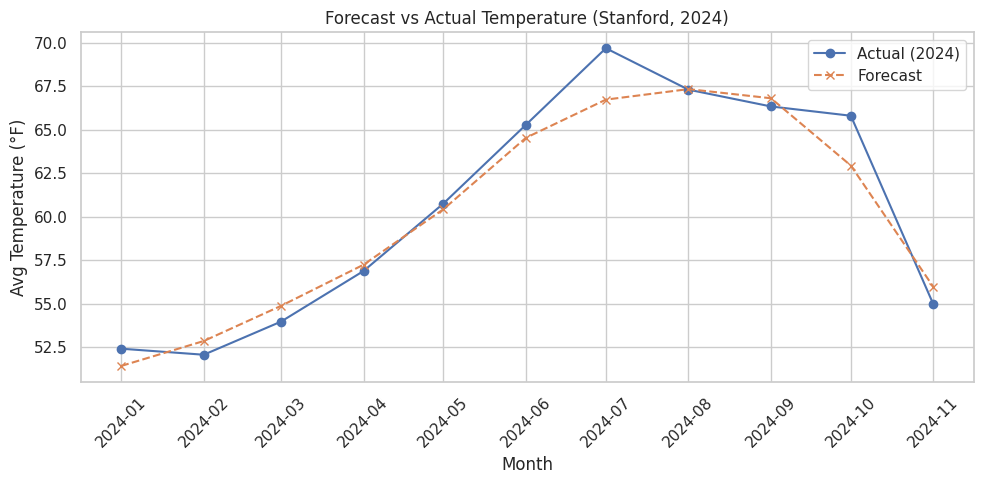

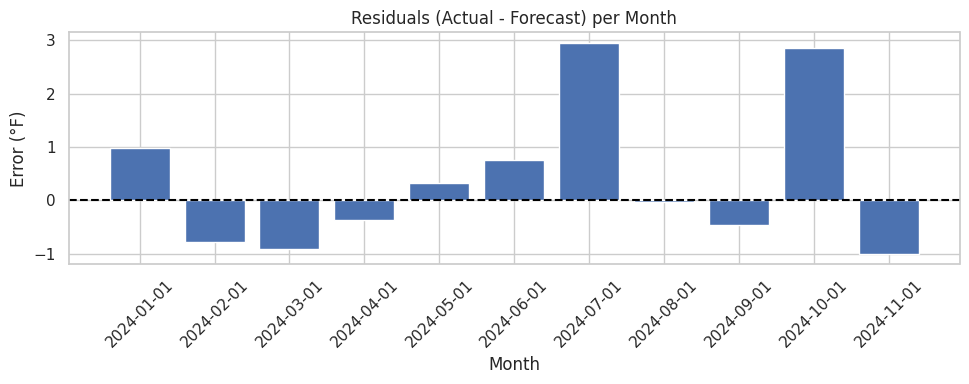

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
import pandas as pd
import numpy as np

# --- CONFIG ---
city = "Stanford University"
covariates = ['dew_point', 'wind_deg', 'pressure', 'rain_hours']

# --- 1) Extract and clean Stanford data from monthly_summary ---
stanford = monthly_summary[monthly_summary['city_name'] == city].copy()

# Convert month to datetime (handles both Period and string)
if pd.api.types.is_period_dtype(stanford['month']):
    stanford['month'] = stanford['month'].dt.to_timestamp()
else:
    stanford['month'] = pd.to_datetime(stanford['month'])

# Sort and set monthly frequency
stanford = stanford.sort_values('month').set_index('month').asfreq('MS')

# Keep relevant columns
cols = ['temp'] + [c for c in covariates if c in stanford.columns]
stanford = stanford[cols]

# --- 2) Align cov_forecasts to month-start timestamps ---
cf = cov_forecasts.copy()

if pd.api.types.is_period_dtype(cf.index):
    cf.index = cf.index.to_timestamp()
else:
    cf.index = pd.to_datetime(cf.index)

cf = cf.sort_index().asfreq('MS')
val_idx = cf.index

# --- 3) Split train / val ---
y = stanford['temp']
y_train = y[y.index < val_idx.min()]
y_val   = y.reindex(val_idx)

# --- 4) Build exogenous matrices ---
X_train = stanford.loc[y_train.index, covariates].apply(pd.to_numeric, errors='coerce')
X_train = X_train.interpolate(limit_direction='both')

X_val = cf[covariates].copy().reindex(val_idx)

# --- 5) Sanity checks ---
assert y_train.index.equals(X_train.index), "Train y/exog misaligned"
assert y_val.index.equals(X_val.index), "Val y/exog misaligned"
if X_val.isnull().any().any():
    raise ValueError("NaNs in cov_forecasts for validation period")

# --- 6) Fit SARIMAX on train, forecast on val ---
model = SARIMAX(
    endog=y_train,
    exog=X_train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
res = model.fit(disp=False)

yhat_val = res.forecast(steps=len(y_val), exog=X_val)

# --- 7) Evaluate and plot ---
rmse = np.sqrt(mean_squared_error(y_val.values, yhat_val.values))
print(f"SARIMAX RMSE ({val_idx.min().date()} to {val_idx.max().date()}): {rmse:.3f}")

try:
    plot_dif(y_val, pd.Series(yhat_val.values, index=yhat_val.index))
except NameError:
    pass



### Random Forest

/tmp/ipython-input-445921513.py:11: DeprecationWarning: is_period_dtype is deprecated and will be removed in a future version. Use `isinstance(dtype, pd.PeriodDtype)` instead
  df['month'] = df['month'].dt.to_timestamp() if pd.api.types.is_period_dtype(df['month']) else pd.to_datetime(df['month'])


RandomForest RMSE (Stanford only, no regressors): 1.59


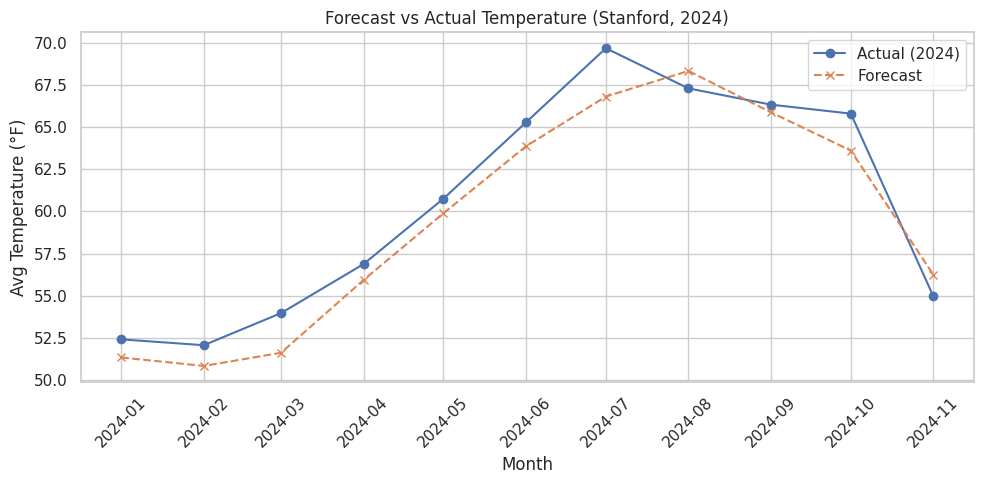

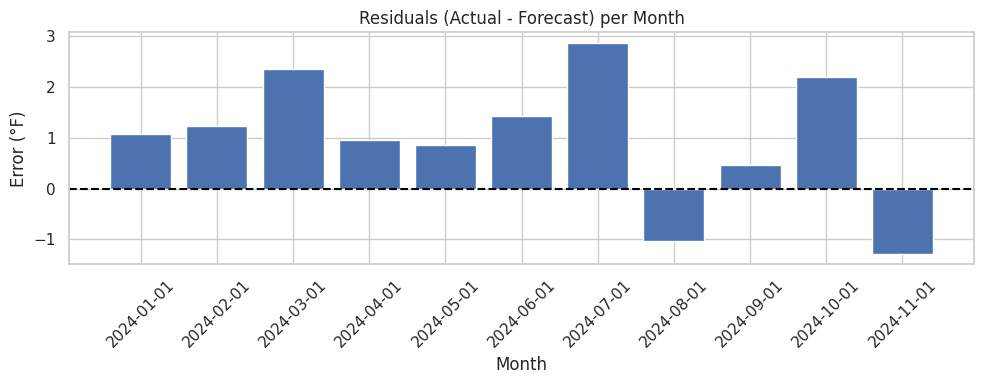

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import pandas as pd
import numpy as np

# --- Stanford-only monthly data ---
CITY = "Stanford University"
VAL_START, VAL_END = "2024-01-01", "2024-11-30"

df = monthly_summary[monthly_summary['city_name'] == CITY].copy()
df['month'] = df['month'].dt.to_timestamp() if pd.api.types.is_period_dtype(df['month']) else pd.to_datetime(df['month'])
df = df.sort_values('month').set_index('month').asfreq('MS')

# --- Minimal features: just time (no lags, no exogenous vars) ---
df['month_num'] = df.index.month
df['year'] = df.index.year

X_all = df[['month_num','year']].copy()
y_all = df['temp'].copy()

# --- Train / Val split ---
X_train = X_all[X_all.index < VAL_START].copy()
y_train = y_all[y_all.index < VAL_START].copy()

val_mask = (X_all.index >= VAL_START) & (X_all.index <= VAL_END)
X_val = X_all.loc[val_mask].copy()
y_val = y_all.loc[val_mask].copy()

# --- Train RF ---
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# --- Predict & evaluate ---
preds = rf.predict(X_val)
rmse = float(np.sqrt(mean_squared_error(y_val, preds)))
print("RandomForest RMSE (Stanford only, no regressors):", round(rmse, 3))

# Optional: plot with your helper
try:
    plot_dif(y_val, pd.Series(preds, index=X_val.index))
except NameError:
    pass


/tmp/ipython-input-2826796447.py:43: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  yhat = float(rf.predict(row))
/tmp/ipython-input-2826796447.py:43: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  yhat = float(rf.predict(row))
/tmp/ipython-input-2826796447.py:43: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  yhat = float(rf.predict(row))
/tmp/ipython-input-2826796447.py:43: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will 

RF RMSE (closed-loop, no lag leakage): 1.59


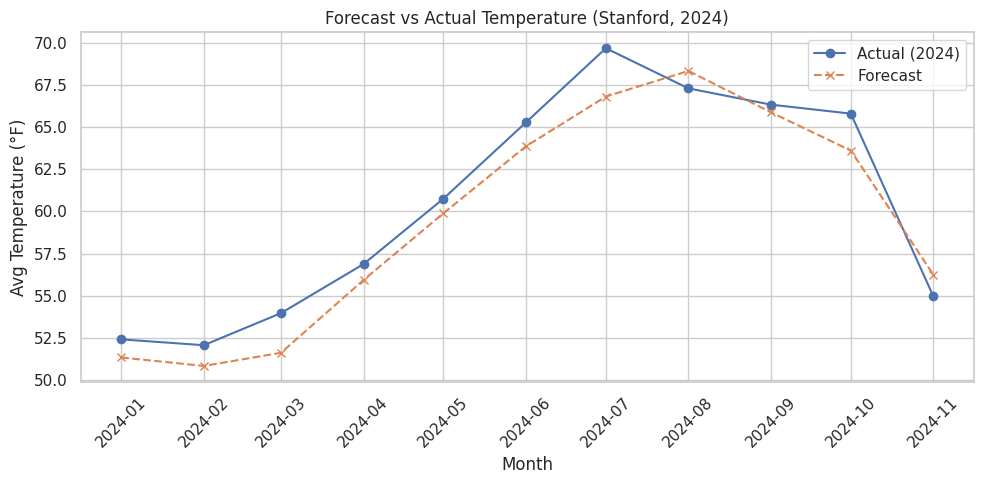

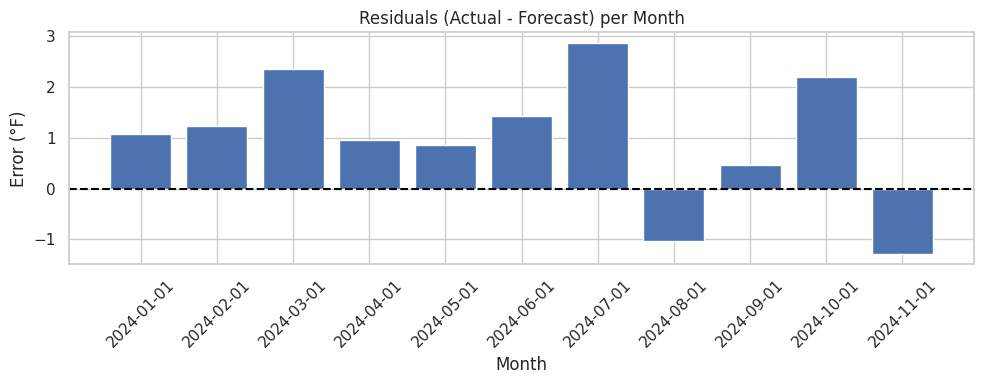

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import pandas as pd
import numpy as np

# --- Identify lag columns present in training ---
lag_cols = [c for c in ['lag1','lag12'] if c in X_train.columns]

# --- Clean TRAIN rows with NaN lags (from early shifts) ---
if lag_cols:
    good_train = y_train.notnull() & (~X_train[lag_cols].isnull().any(axis=1))
else:
    good_train = y_train.notnull()

X_train_cln = X_train.loc[good_train].copy()
y_train_cln = y_train.loc[good_train].copy()

# --- Fit RF as usual ---
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_cln, y_train_cln)

# --- Build X_val base WITHOUT true lag columns (avoid peeking) ---
X_val_base = X_val.drop(columns=lag_cols, errors='ignore').copy()

# Make sure non-lag columns align with training
nonlag_cols_train = [c for c in X_train_cln.columns if c not in lag_cols]
X_val_base = X_val_base.reindex(columns=nonlag_cols_train, fill_value=0.0)

# --- CLOSED-LOOP roll-out over validation months ---
preds = []
hist = y_train_cln.sort_index().copy()  # seed with training actuals only

for ts in X_val_base.index:
    row = X_val_base.loc[[ts]].copy()
    # Rebuild lags from our own rolling history (NO true validation lags)
    if 'lag1' in lag_cols:
        row['lag1'] = hist.iloc[-1] if len(hist) >= 1 else hist.mean()
    if 'lag12' in lag_cols:
        row['lag12'] = hist.iloc[-12] if len(hist) >= 12 else hist.iloc[-1]
    # Ensure column order matches training
    row = row.reindex(columns=X_train_cln.columns, fill_value=0.0)

    yhat = float(rf.predict(row))
    preds.append(yhat)
    hist.loc[ts] = yhat  # update history for next step's lags

preds = pd.Series(preds, index=X_val_base.index)

# --- Evaluate ---
rmse = float(np.sqrt(mean_squared_error(y_val.loc[preds.index], preds.values)))
print("RF RMSE (closed-loop, no lag leakage):", round(rmse, 3))

# Optional: plot with your helper
try:
    plot_dif(y_val, preds)
except NameError:
    pass


# Prophet Model

Prophet (no regressors) RMSE on 2024-01-01..2024-11-30: 1.601


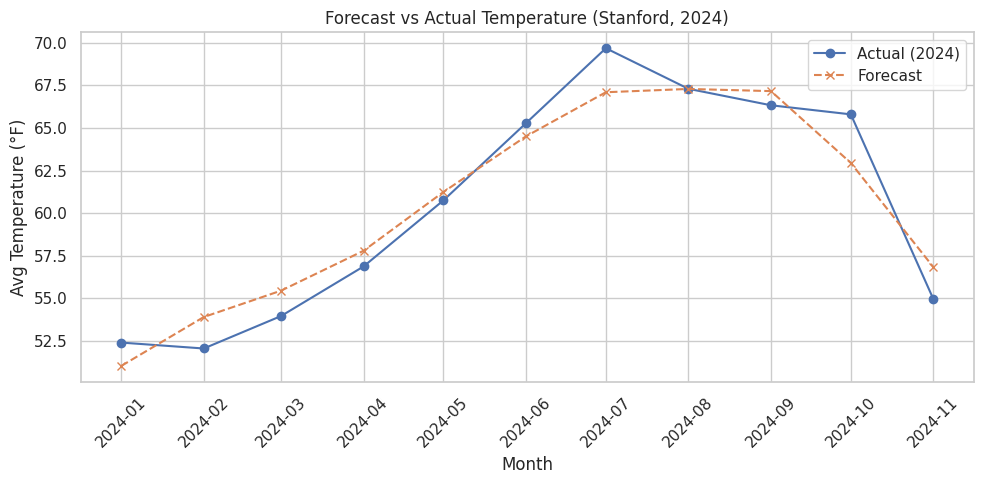

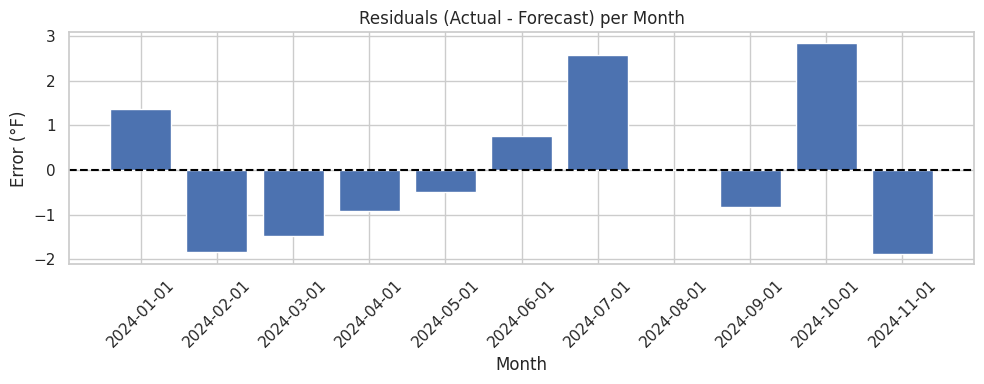

In [ ]:
from prophet import Prophet
from sklearn.metrics import mean_squared_error
import pandas as pd
import numpy as np

# --- Stanford monthly series from your monthly_summary ---
stanford = monthly_summary[monthly_summary['city_name'] == 'Stanford University'][['month','temp']].copy()
stanford['ds'] = pd.to_datetime(stanford['month'].dt.to_timestamp() if hasattr(stanford['month'], 'dt') else stanford['month'])
stanford['y']  = stanford['temp']
stanford = stanford[['ds','y']].sort_values('ds').dropna()

# --- Splits (match XGB dates) ---
train_df = stanford[stanford['ds'] < '2024-01-01'][['ds','y']].copy()
val_df   = stanford[(stanford['ds'] >= '2024-01-01') & (stanford['ds'] <= '2024-11-30')][['ds','y']].copy()

# --- Fit Prophet (no regressors) ---
m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
m.fit(train_df)

# --- Forecast exactly the validation window ---
fc_val = m.predict(val_df[['ds']])

# --- RMSE on 2023-01-01 .. 2024-11-30 ---
rmse = np.sqrt(mean_squared_error(val_df['y'].values, fc_val['yhat'].values))
print(f"Prophet (no regressors) RMSE on 2024-01-01..2024-11-30: {rmse:.3f}")

# --- Plot exactly the same window with your helper ---
actual_val   = pd.Series(val_df['y'].values, index=val_df['ds'])
forecast_val = pd.Series(fc_val['yhat'].values, index=fc_val['ds'])
plot_dif(actual_val, forecast_val)


In [ ]:
from prophet import Prophet
import pandas as pd
import numpy as np

# Regressors to forecast
regs = ['pressure', 'dew_point', 'humidity', 'rain_hours', 'snow_hours']

# Build monthly Stanford base with these columns
base = monthly_summary[monthly_summary['city_name']=='Stanford University'][['month']+regs].copy()
base['ds'] = pd.to_datetime(base['month'].dt.to_timestamp())
base = base[['ds']+regs].sort_values('ds')

# Train/val dates (same as temp)
train_mask = base['ds'] < '2024-01-01'
val_mask   = (base['ds'] >= '2024-01-01') & (base['ds'] <= '2024-11-30')
future_ds  = base.loc[val_mask, 'ds'].reset_index(drop=True)

# Forecast each reg
pred_regs = pd.DataFrame({'ds': future_ds})
for r in regs:
    series = base[['ds', r]].dropna().sort_values('ds')
    # Make sure we have some training rows
    if (series['ds'] < '2024-01-01').sum() == 0:
        raise ValueError(f"No pre-2024 data for regressor '{r}'.")
    train_r = series[series['ds'] < '2024-01-01'][['ds', r]].rename(columns={r:'y'})
    m_r = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
    m_r.fit(train_r)
    fc_r = m_r.predict(pd.DataFrame({'ds': future_ds}))
    pred_regs[r] = fc_r['yhat'].to_numpy()

# Safety: if any NaNs remain, fill from last known (shouldn’t be needed, but harmless)
pred_regs[regs] = pred_regs[regs].interpolate(limit_direction='both').bfill().ffill()


In [ ]:
from sklearn.metrics import mean_squared_error

# Temperature baseline frames you already have
stanford = monthly_summary[monthly_summary['city_name']=='Stanford University'][['month','temp']].copy()
stanford['ds'] = pd.to_datetime(stanford['month'].dt.to_timestamp())
stanford['y']  = stanford['temp']
stanford = stanford[['ds','y']].sort_values('ds').dropna()

train_df = stanford[stanford['ds'] < '2024-01-01'][['ds','y']].copy()
val_df   = stanford[(stanford['ds'] >= '2024-01-01') & (stanford['ds'] <= '2024-11-30')][['ds','y']].copy()

# Merge predicted regressors onto val ds
future_val = val_df[['ds']].merge(pred_regs, on='ds', how='inner')

# Train main model on historical truth of regressors
hist_regs = monthly_summary[monthly_summary['city_name']=='Stanford University'][['month']+regs].copy()
hist_regs['ds'] = pd.to_datetime(hist_regs['month'].dt.to_timestamp())
hist_regs = hist_regs[['ds']+regs].sort_values('ds')
train_regs = hist_regs[hist_regs['ds'] < '2024-01-01']

train_full = train_df.merge(train_regs, on='ds', how='inner')
train_full[regs] = train_full[regs].interpolate(limit_direction='both').bfill().ffill()

# Fit Prophet with regressors
m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
for r in regs:
    m.add_regressor(r)
m.fit(train_full[['ds','y']+regs])

# Predict and evaluate on 2023-01-01..2024-11-30
fc_val = m.predict(future_val[['ds']+regs])
rmse = float(np.sqrt(mean_squared_error(val_df.set_index('ds').loc[fc_val['ds'],'y'].values, fc_val['yhat'].values)))
print(f"Prophet (with Prophet-forecasted regressors) RMSE on 2023-01-01..2024-11-30: {rmse:.3f}")


Prophet (with Prophet-forecasted regressors) RMSE on 2023-01-01..2024-11-30: 1.619


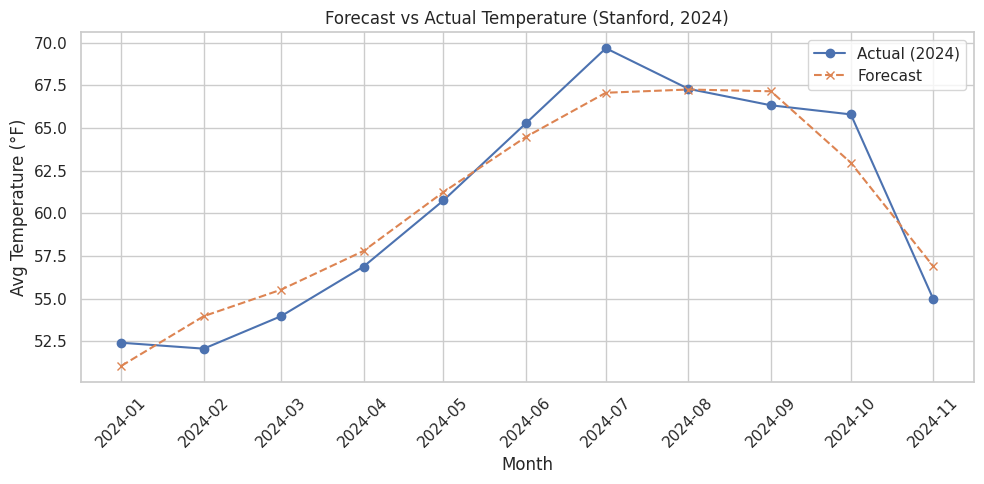

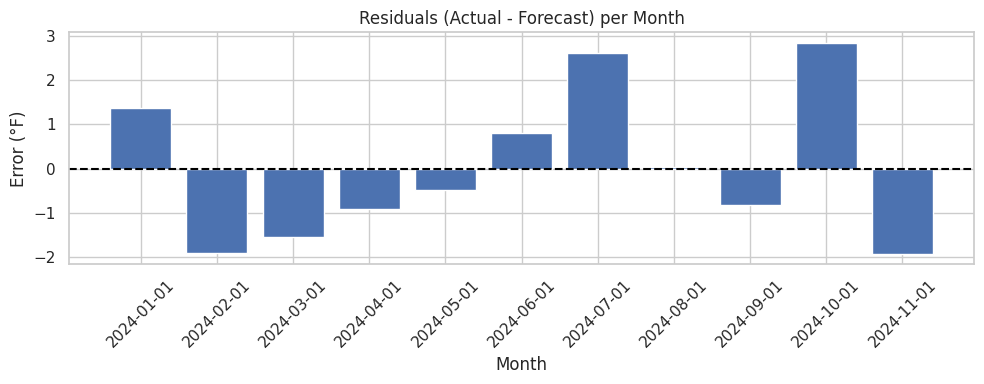

In [ ]:
# Use your plot_dif over the exact window
actual_series   = val_df.set_index('ds')['y']
forecast_series = pd.Series(fc_val['yhat'].values, index=fc_val['ds'])
plot_dif(actual_series, forecast_series)


[Prophet Flexible - full history] RMSE 2024-01..2024-11: 1.651
[Prophet Flexible - recent window (~15y)] RMSE 2024-01..2024-11: 3.986
Best flexible Prophet: Prophet Flexible (full history), RMSE=1.651


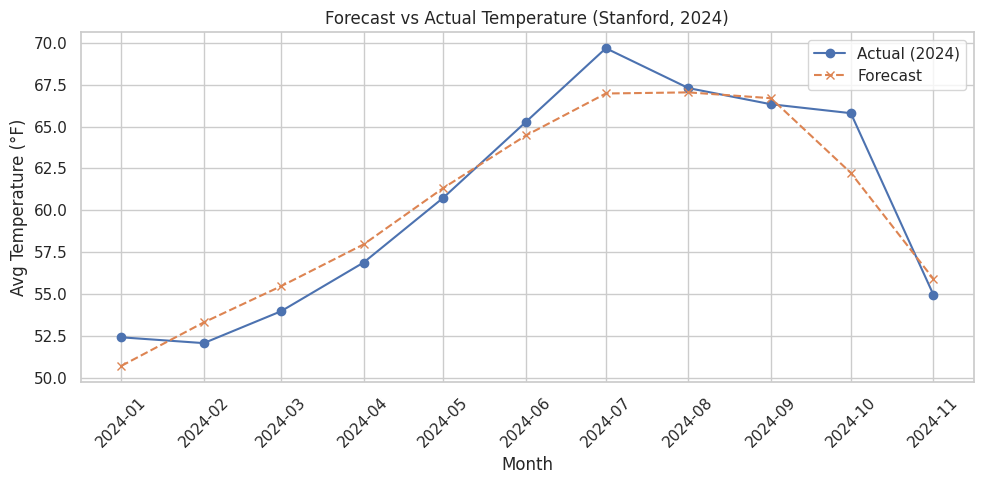

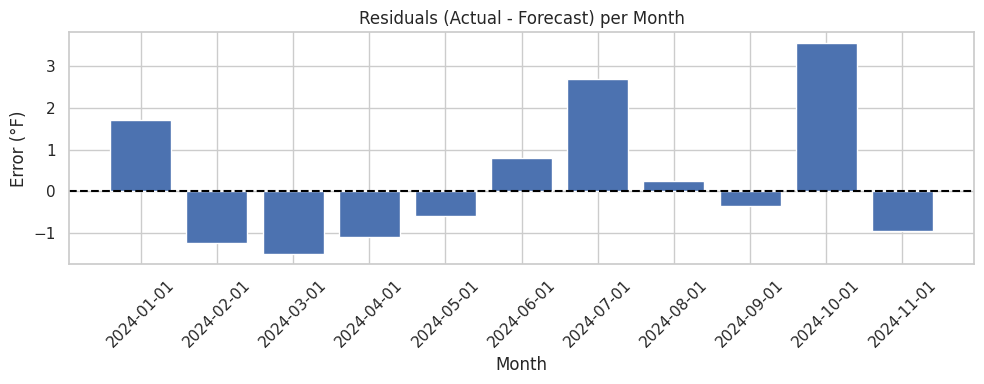

In [ ]:
from prophet import Prophet
from sklearn.metrics import mean_squared_error
import pandas as pd
import numpy as np

# --- Stanford monthly series from your monthly_summary ---
stanford = monthly_summary[monthly_summary['city_name'] == 'Stanford University'][['month','temp']].copy()
stanford['ds'] = pd.to_datetime(stanford['month'].dt.to_timestamp() if hasattr(stanford['month'], 'dt') else stanford['month'])
stanford['y']  = stanford['temp']
stanford = stanford[['ds','y']].sort_values('ds').dropna()

# --- Splits (match your XGB dates) ---
train_df = stanford[stanford['ds'] < '2024-01-01'][['ds','y']].copy()
val_df   = stanford[(stanford['ds'] >= '2024-01-01') & (stanford['ds'] <= '2024-11-30')][['ds','y']].copy()

# ========== V1: More-flexible Prophet on full history ==========
m1 = Prophet(
    yearly_seasonality=15,       # higher Fourier order than default 10 -> more seasonal flexibility
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.5, # larger -> more trend wiggle
    n_changepoints=40,           # more potential changepoints
    changepoint_range=0.95,      # allow changepoints closer to the present (default is 0.8)
    seasonality_mode='additive', # temps usually additive; switch to 'multiplicative' to test
    seasonality_prior_scale=10.0 # keep default-ish; could tune 5–15 if needed
)
m1.fit(train_df)
fc1 = m1.predict(val_df[['ds']])
rmse1 = float(np.sqrt(mean_squared_error(val_df['y'].values, fc1['yhat'].values)))
print(f"[Prophet Flexible - full history] RMSE 2024-01..2024-11: {rmse1:.3f}")

# ========== V2: Same flexibility, but train only on the last ~15 years ==========
years_back = 15
cutoff = train_df['ds'].max() - pd.DateOffset(years=years_back)
train_recent = train_df[train_df['ds'] >= cutoff].copy()

# Make sure we still have enough seasons; if not, fall back to full train
if len(train_recent) < 4*12:
    train_recent = train_df.copy()

m2 = Prophet(
    yearly_seasonality=15,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.5,
    n_changepoints=40,
    changepoint_range=0.95,
    seasonality_mode='additive',
    seasonality_prior_scale=10.0
)
m2.fit(train_recent)
fc2 = m2.predict(val_df[['ds']])
rmse2 = float(np.sqrt(mean_squared_error(val_df['y'].values, fc2['yhat'].values)))
print(f"[Prophet Flexible - recent window (~{years_back}y)] RMSE 2024-01..2024-11: {rmse2:.3f}")

# --- Pick best variant and plot ---
if rmse2 < rmse1:
    best_fc = fc2
    tag = f"Prophet Flexible (recent {years_back}y)"
    best_rmse = rmse2
else:
    best_fc = fc1
    tag = "Prophet Flexible (full history)"
    best_rmse = rmse1

print(f"Best flexible Prophet: {tag}, RMSE={best_rmse:.3f}")

actual_val   = pd.Series(val_df['y'].values, index=val_df['ds'])
forecast_val = pd.Series(best_fc['yhat'].values, index=best_fc['ds'])
try:
    plot_dif(actual_val, forecast_val)
except NameError:
    pass


In [ ]:
from sklearn.metrics import mean_squared_error

# Temperature baseline frames you already have
stanford = monthly_summary[monthly_summary['city_name']=='Stanford University'][['month','temp']].copy()
stanford['ds'] = pd.to_datetime(stanford['month'].dt.to_timestamp())
stanford['y']  = stanford['temp']
stanford = stanford[['ds','y']].sort_values('ds').dropna()

train_df = stanford[stanford['ds'] < '2024-01-01'][['ds','y']].copy()
val_df   = stanford[(stanford['ds'] >= '2024-01-01') & (stanford['ds'] <= '2024-11-30')][['ds','y']].copy()

# Merge predicted regressors onto val ds
future_val = val_df[['ds']].merge(pred_regs, on='ds', how='inner')

# Train main model on historical truth of regressors
hist_regs = monthly_summary[monthly_summary['city_name']=='Stanford University'][['month']+regs].copy()
hist_regs['ds'] = pd.to_datetime(hist_regs['month'].dt.to_timestamp())
hist_regs = hist_regs[['ds']+regs].sort_values('ds')
train_regs = hist_regs[hist_regs['ds'] < '2024-01-01']

train_full = train_df.merge(train_regs, on='ds', how='inner')
train_full[regs] = train_full[regs].interpolate(limit_direction='both').bfill().ffill()

# Fit Prophet with regressors
m = Prophet(
    yearly_seasonality=15,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.5,
    n_changepoints=40,
    changepoint_range=0.95,
    seasonality_mode='additive',
    seasonality_prior_scale=10.0
)
for r in regs:
    m.add_regressor(r)
m.fit(train_full[['ds','y']+regs])

# Predict and evaluate on 2023-01-01..2024-11-30
fc_val = m.predict(future_val[['ds']+regs])
rmse = float(np.sqrt(mean_squared_error(val_df.set_index('ds').loc[fc_val['ds'],'y'].values, fc_val['yhat'].values)))
print(f"Prophet (with Prophet-forecasted regressors) RMSE on 2023-01-01..2024-11-30: {rmse:.3f}")

Prophet (with Prophet-forecasted regressors) RMSE on 2023-01-01..2024-11-30: 1.608


CV | ys=10, cps=0.2, cpr=0.80, mode=additive      -> RMSE=1.868
CV | ys=10, cps=0.2, cpr=0.80, mode=multiplicative -> RMSE=1.882
CV | ys=10, cps=0.2, cpr=0.95, mode=additive      -> RMSE=1.862
CV | ys=10, cps=0.2, cpr=0.95, mode=multiplicative -> RMSE=1.871
CV | ys=10, cps=0.5, cpr=0.80, mode=additive      -> RMSE=1.828
CV | ys=10, cps=0.5, cpr=0.80, mode=multiplicative -> RMSE=1.836
CV | ys=10, cps=0.5, cpr=0.95, mode=additive      -> RMSE=2.094
CV | ys=10, cps=0.5, cpr=0.95, mode=multiplicative -> RMSE=2.122
CV | ys=10, cps=1.0, cpr=0.80, mode=additive      -> RMSE=1.815
CV | ys=10, cps=1.0, cpr=0.80, mode=multiplicative -> RMSE=1.821
CV | ys=10, cps=1.0, cpr=0.95, mode=additive      -> RMSE=2.166
CV | ys=10, cps=1.0, cpr=0.95, mode=multiplicative -> RMSE=2.212
CV | ys=15, cps=0.2, cpr=0.80, mode=additive      -> RMSE=1.840
CV | ys=15, cps=0.2, cpr=0.80, mode=multiplicative -> RMSE=1.824
CV | ys=15, cps=0.2, cpr=0.95, mode=additive      -> RMSE=1.828
CV | ys=15, cps=0.2, cpr=0.95, mo

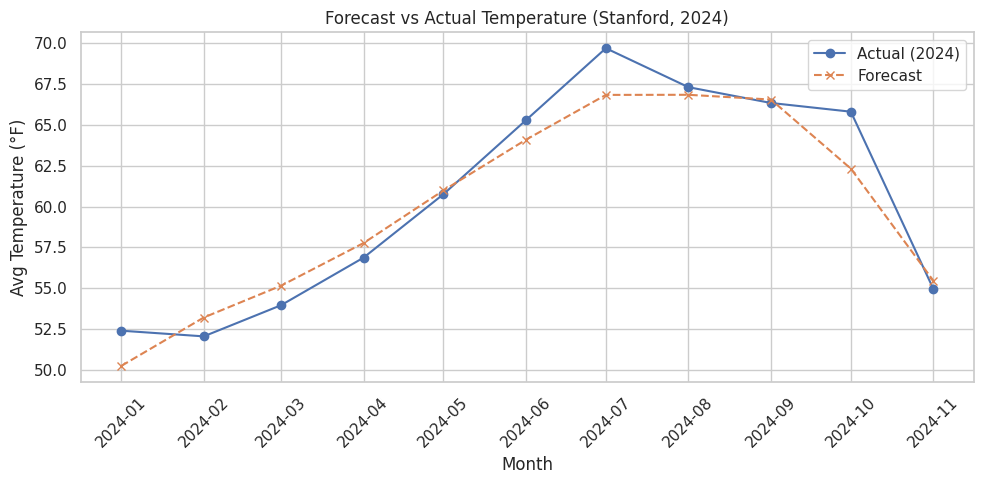

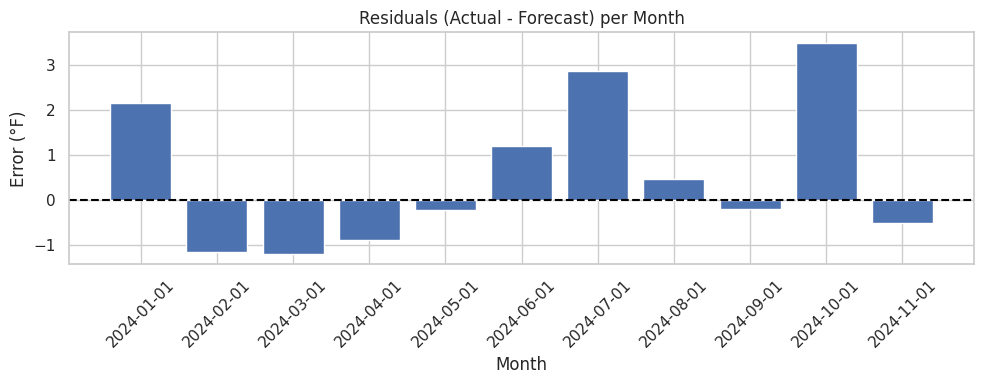

In [ ]:
from prophet import Prophet
from sklearn.metrics import mean_squared_error
import pandas as pd, numpy as np, itertools, warnings

# ---------------- 0) Stanford monthly series ----------------
CITY = "Stanford University"
VAL_START = "2024-01-01"
VAL_END   = "2024-11-30"   # inclusive end for your window

# Build ds/y (monthly start stamps)
stan = monthly_summary[monthly_summary['city_name'] == CITY].copy()
stan['ds'] = (stan['month'].dt.to_timestamp()
              if hasattr(stan['month'], 'dt') else pd.to_datetime(stan['month']))
stan['y']  = stan['temp'].astype(float)
stan = stan[['ds','y']].dropna().sort_values('ds')

train_df = stan[stan['ds'] < VAL_START].copy()                 # strictly pre-2023
val_df   = stan[(stan['ds'] >= VAL_START) & (stan['ds'] <= VAL_END)][['ds','y']].copy()

# ---------------- 1) Expanding-window CV (leakage-safe) ----------------
def prophet_cv_rmse(train_df: pd.DataFrame, params: dict,
                    n_folds=3, val_len=12, min_train=36) -> float:
    """
    Expanding-window CV on pre-2023 data.
    Each fold: fit on early part, forecast next `val_len` months, compute RMSE.
    """
    df = train_df.sort_values('ds').reset_index(drop=True)
    n = len(df)
    # shrink folds if history too short
    while n_folds * val_len + min_train > n and n_folds > 0:
        n_folds -= 1
    if n_folds == 0:
        return np.inf

    rmses = []
    for k in range(n_folds, 0, -1):
        va_start = n - k * val_len
        tr_end   = va_start
        if tr_end < min_train:
            continue

        tr = df.iloc[:tr_end][['ds','y']]
        va = df.iloc[tr_end:tr_end + val_len][['ds','y']]
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                m = Prophet(
                    yearly_seasonality=params['yearly_seasonality'],
                    weekly_seasonality=False,
                    daily_seasonality=False,
                    changepoint_prior_scale=params['changepoint_prior_scale'],
                    changepoint_range=params['changepoint_range'],
                    seasonality_mode=params['seasonality_mode'],
                    n_changepoints=40,
                )
                m.fit(tr)
                fc = m.predict(va[['ds']])['yhat'].to_numpy()
            rmse = float(np.sqrt(mean_squared_error(va['y'].to_numpy(), fc)))
            rmses.append(rmse)
        except Exception:
            rmses.append(np.inf)

    return float(np.mean(rmses)) if rmses else np.inf

# ---------------- 2) 36-combo grid (≈30–40 models) ----------------
grid = list(itertools.product(
    [10, 15, 20],           # yearly_seasonality (Fourier order)
    [0.2, 0.5, 1.0],        # changepoint_prior_scale
    [0.80, 0.95],           # changepoint_range
    ['additive', 'multiplicative'],  # seasonality_mode
))
best_params, best_cv = None, np.inf

for ys, cps, cpr, mode in grid:
    params = dict(
        yearly_seasonality=ys,
        changepoint_prior_scale=cps,
        changepoint_range=cpr,
        seasonality_mode=mode,
    )
    cv_rmse = prophet_cv_rmse(train_df, params, n_folds=3, val_len=12, min_train=36)
    print(f"CV | ys={ys:>2}, cps={cps:>3}, cpr={cpr:.2f}, mode={mode:<13} -> RMSE={cv_rmse:.3f}")
    if cv_rmse < best_cv:
        best_cv, best_params = cv_rmse, params

print("\nBest CV params:", best_params)
print(f"Mean CV RMSE (pre-2023 folds): {best_cv:.3f}")

# ---------------- 3) Refit best on pre-2023 and eval on 2023-01..2024-11 ----------------
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    m_best = Prophet(
        yearly_seasonality=best_params['yearly_seasonality'],
        weekly_seasonality=False,
        daily_seasonality=False,
        changepoint_prior_scale=best_params['changepoint_prior_scale'],
        changepoint_range=best_params['changepoint_range'],
        seasonality_mode=best_params['seasonality_mode'],
        n_changepoints=40,
    )
    m_best.fit(train_df[['ds','y']])

fc_val = m_best.predict(val_df[['ds']])
final_rmse = float(np.sqrt(mean_squared_error(val_df['y'].to_numpy(),
                                              fc_val['yhat'].to_numpy())))
print(f"Final Prophet RMSE on {VAL_START}..{VAL_END}: {final_rmse:.3f}")

# Optional: plot with your helper
try:
    plot_dif(val_df.set_index('ds')['y'], pd.Series(fc_val['yhat'].values, index=fc_val['ds']))
except NameError:
    pass
